In [1]:
import numpy as np
import pandas as pd
import netCDF4 as nc
import zarr
import glob
import cftime, datetime
import glob
from concurrent.futures import ProcessPoolExecutor
import time
import metpy.interpolate as mpi
from scipy.interpolate import RegularGridInterpolator
import os

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## load in AIDE-WACCM from here

In [2]:
save_dir = "/home/ubuntu/noah/1997_daily_means_aide/"

# Reload
T_zonal_array = np.load(f"{save_dir}/T_zonal_members_1997_2000.npy")  # (10, n_days, 17, 180)
U_zonal_array = np.load(f"{save_dir}/U_zonal_members_1997_2000.npy")
w_zonal_array = np.load(f"{save_dir}/w_zonal_members_1997_2000.npy")

# Ensemble mean across time
T_annual_zonal_aide = np.nanmean([np.nanmean(m, axis=0) for m in T_zonal_array], axis=0)  # (17, 180)
U_annual_zonal_aide = np.nanmean([np.nanmean(m, axis=0) for m in U_zonal_array], axis=0)  # (17, 180)
w_annual_zonal_aide = np.nanmean([np.nanmean(m, axis=0) for m in w_zonal_array], axis=0)  # (17, 180)
print(T_annual_zonal_aide.shape, U_annual_zonal_aide.shape, w_annual_zonal_aide.shape)

T_std_zonal_aide = np.nanmean([np.nanstd(m, axis=0) for m in T_zonal_array], axis=0)  # (17, 180)
U_std_zonal_aide = np.nanmean([np.nanstd(m, axis=0) for m in U_zonal_array], axis=0)  # (17, 180)
w_std_zonal_aide = np.nanmean([np.nanstd(m, axis=0) for m in w_zonal_array], axis=0)  # (17, 180)

(17, 180) (17, 180) (17, 180)


In [3]:
# T/U_zonal_members_allyears shape: (10, 1460, 17, 180)
# Each year is 365 days, so:
# Year 1 (1997): days 0-364
# Year 2 (1998): days 365-729
# Year 3 (1999): days 730-1094
# Year 4 (2000): days 1095-1459

year_starts = [0, 365, 730, 1095]

# DJF: Jan(0:31) + Feb(31:59) + Dec(335:365) for each year
# JJA: Jun(151:182) + Jul(182:213) + Aug(213:243) for each year

T_DJF_list, U_DJF_list, w_DJF_list = [], [], []
T_JJA_list, U_JJA_list, w_JJA_list = [], [], []

for ys in year_starts:
    # DJF — Jan + Feb of this year, Dec of this year
    T_DJF_list.append(np.concatenate([
        T_zonal_array[:, ys+0:ys+59,   :, :],  # Jan + Feb
        T_zonal_array[:, ys+335:ys+365, :, :]  # Dec
    ], axis=1))
    U_DJF_list.append(np.concatenate([
        U_zonal_array[:, ys+0:ys+59,   :, :],
        U_zonal_array[:, ys+335:ys+365, :, :]
    ], axis=1))
    w_DJF_list.append(np.concatenate([
        w_zonal_array[:, ys+0:ys+59,   :, :],
        w_zonal_array[:, ys+335:ys+365, :, :]
    ], axis=1))

    # JJA — Jun + Jul + Aug
    T_JJA_list.append(T_zonal_array[:, ys+151:ys+243, :, :])
    U_JJA_list.append(U_zonal_array[:, ys+151:ys+243, :, :])
    w_JJA_list.append(w_zonal_array[:, ys+151:ys+243, :, :])

# Concatenate all years together along time axis
T_DJF_aide = np.concatenate(T_DJF_list, axis=1)  # (10, 4*90, 17, 180)
U_DJF_aide = np.concatenate(U_DJF_list, axis=1)
w_DJF_aide = np.concatenate(w_DJF_list, axis=1)
T_JJA_aide = np.concatenate(T_JJA_list, axis=1)  # (10, 4*92, 17, 180)
U_JJA_aide = np.concatenate(U_JJA_list, axis=1)
w_JJA_aide = np.concatenate(w_JJA_list, axis=1)

print(f"DJF shape: {T_DJF_aide.shape}")
print(f"JJA shape: {T_JJA_aide.shape}")

# Ensemble mean seasonal zonal mean
T_DJF_zonal_aide = np.nanmean(np.nanmean(T_DJF_aide, axis=1), axis=0)  # (mi, time, height, lat)  take mean across time axis (1) and then across members (0)
T_JJA_zonal_aide = np.nanmean(np.nanmean(T_JJA_aide, axis=1), axis=0)
U_DJF_zonal_aide = np.nanmean(np.nanmean(U_DJF_aide, axis=1), axis=0)
U_JJA_zonal_aide = np.nanmean(np.nanmean(U_JJA_aide, axis=1), axis=0)
w_DJF_zonal_aide = np.nanmean(np.nanmean(w_DJF_aide, axis=1), axis=0)
w_JJA_zonal_aide = np.nanmean(np.nanmean(w_JJA_aide, axis=1), axis=0)

T_DJF_std_aide = np.nanmean(np.nanstd(T_DJF_aide, axis=1), axis=0)  # std over time, then mean across members
T_JJA_std_aide = np.nanmean(np.nanstd(T_JJA_aide, axis=1), axis=0)
U_DJF_std_aide = np.nanmean(np.nanstd(U_DJF_aide, axis=1), axis=0)
U_JJA_std_aide = np.nanmean(np.nanstd(U_JJA_aide, axis=1), axis=0)
w_DJF_std_aide = np.nanmean(np.nanstd(w_DJF_aide, axis=1), axis=0)
w_JJA_std_aide = np.nanmean(np.nanstd(w_JJA_aide, axis=1), axis=0)

print(f"Final shapes: {T_DJF_zonal_aide.shape}, {T_JJA_zonal_aide.shape}")

DJF shape: (10, 356, 17, 180)
JJA shape: (10, 368, 17, 180)
Final shapes: (17, 180), (17, 180)


## load in CESM-WACCM from here

In [6]:
T_zonal_cesm = np.load('/home/ubuntu/noah/1997_2000_daily_means_cesm/T_zonal_cesm_1997_2000.npy')
U_zonal_cesm = np.load('/home/ubuntu/noah/1997_2000_daily_means_cesm/U_zonal_cesm_1997_2000.npy')
w_zonal_cesm = np.load('/home/ubuntu/noah/1997_2000_daily_means_cesm/w_zonal_cesm_1997_2000.npy')
print(f"Reloaded shapes: T={T_zonal_cesm.shape}, U={U_zonal_cesm.shape}, w={w_zonal_cesm.shape}")
# Annual zonal mean
T_annual_zonal_cesm = np.nanmean(T_zonal_cesm, axis=0)
U_annual_zonal_cesm = np.nanmean(U_zonal_cesm, axis=0)
w_annual_zonal_cesm = np.nanmean(w_zonal_cesm, axis=0)

T_std_zonal_cesm = np.nanstd(T_zonal_cesm, axis=0)
U_std_zonal_cesm = np.nanstd(U_zonal_cesm, axis=0)
w_std_zonal_cesm = np.nanstd(w_zonal_cesm, axis=0)
print(f"Final shapes: T={T_annual_zonal_cesm.shape}, U={U_annual_zonal_cesm.shape}, w={w_annual_zonal_cesm.shape}")

Reloaded shapes: T=(1460, 17, 180), U=(1460, 17, 180), w=(1460, 17, 180)
Final shapes: T=(17, 180), U=(17, 180), w=(17, 180)


/tmp/ipykernel_4175261/4234250681.py:6: RuntimeWarning: Mean of empty slice
  T_annual_zonal_cesm = np.nanmean(T_zonal_cesm, axis=0)
/tmp/ipykernel_4175261/4234250681.py:7: RuntimeWarning: Mean of empty slice
  U_annual_zonal_cesm = np.nanmean(U_zonal_cesm, axis=0)
/tmp/ipykernel_4175261/4234250681.py:8: RuntimeWarning: Mean of empty slice
  w_annual_zonal_cesm = np.nanmean(w_zonal_cesm, axis=0)
/home/ubuntu/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [7]:
year_starts = [0, 365, 730, 1095]

T_DJF_list, U_DJF_list, w_DJF_list = [], [], []
T_JJA_list, U_JJA_list, w_JJA_list = [], [], []

for ys in year_starts:
    # DJF: Jan + Feb + Dec
    T_DJF_list.append(np.concatenate([
        T_zonal_cesm[ys+0:ys+59,   :, :],   # Jan + Feb
        T_zonal_cesm[ys+335:ys+365, :, :]   # Dec
    ], axis=0))
    U_DJF_list.append(np.concatenate([
        U_zonal_cesm[ys+0:ys+59,   :, :],
        U_zonal_cesm[ys+335:ys+365, :, :]
    ], axis=0))

    w_DJF_list.append(np.concatenate([
        w_zonal_cesm[ys+0:ys+59,   :, :],
        w_zonal_cesm[ys+335:ys+365, :, :]
    ], axis=0))

    # JJA: Jun + Jul + Aug
    T_JJA_list.append(T_zonal_cesm[ys+151:ys+243, :, :])
    U_JJA_list.append(U_zonal_cesm[ys+151:ys+243, :, :])
    w_JJA_list.append(w_zonal_cesm[ys+151:ys+243, :, :])
# Concatenate all years
T_DJF_cesm = np.concatenate(T_DJF_list, axis=0)  # (4*90, 17, 180)
U_DJF_cesm = np.concatenate(U_DJF_list, axis=0)
w_DJF_cesm = np.concatenate(w_DJF_list, axis=0)
T_JJA_cesm = np.concatenate(T_JJA_list, axis=0)  # (4*92, 17, 180)
U_JJA_cesm = np.concatenate(U_JJA_list, axis=0)
w_JJA_cesm = np.concatenate(w_JJA_list, axis=0)

print(f"DJF shapes: T={T_DJF_cesm.shape}, U={U_DJF_cesm.shape}, w={w_DJF_cesm.shape}")
print(f"JJA shapes: T={T_JJA_cesm.shape}, U={U_JJA_cesm.shape}, w={w_JJA_cesm.shape}")

# Seasonal zonal means
T_DJF_zonal_cesm = np.nanmean(T_DJF_cesm, axis=0)  # (17, 180)
T_JJA_zonal_cesm = np.nanmean(T_JJA_cesm, axis=0)
U_DJF_zonal_cesm = np.nanmean(U_DJF_cesm, axis=0)
U_JJA_zonal_cesm = np.nanmean(U_JJA_cesm, axis=0)
w_DJF_zonal_cesm = np.nanmean(w_DJF_cesm, axis=0)
w_JJA_zonal_cesm = np.nanmean(w_JJA_cesm, axis=0)

# Seasonal variability (std dev across time)
T_DJF_std_cesm = np.nanstd(T_DJF_cesm, axis=0)
T_JJA_std_cesm = np.nanstd(T_JJA_cesm, axis=0)
U_DJF_std_cesm = np.nanstd(U_DJF_cesm, axis=0)
U_JJA_std_cesm = np.nanstd(U_JJA_cesm, axis=0)
w_DJF_std_cesm = np.nanstd(w_DJF_cesm, axis=0)
w_JJA_std_cesm = np.nanstd(w_JJA_cesm, axis=0)

print(f"Final seasonal shapes: {T_DJF_zonal_cesm.shape}, {T_JJA_zonal_cesm.shape}")

DJF shapes: T=(356, 17, 180), U=(356, 17, 180), w=(356, 17, 180)
JJA shapes: T=(368, 17, 180), U=(368, 17, 180), w=(368, 17, 180)
Final seasonal shapes: (17, 180), (17, 180)


/tmp/ipykernel_4175261/126368243.py:38: RuntimeWarning: Mean of empty slice
  T_DJF_zonal_cesm = np.nanmean(T_DJF_cesm, axis=0)  # (17, 180)
/tmp/ipykernel_4175261/126368243.py:39: RuntimeWarning: Mean of empty slice
  T_JJA_zonal_cesm = np.nanmean(T_JJA_cesm, axis=0)
/tmp/ipykernel_4175261/126368243.py:40: RuntimeWarning: Mean of empty slice
  U_DJF_zonal_cesm = np.nanmean(U_DJF_cesm, axis=0)
/tmp/ipykernel_4175261/126368243.py:41: RuntimeWarning: Mean of empty slice
  U_JJA_zonal_cesm = np.nanmean(U_JJA_cesm, axis=0)
/tmp/ipykernel_4175261/126368243.py:42: RuntimeWarning: Mean of empty slice
  w_DJF_zonal_cesm = np.nanmean(w_DJF_cesm, axis=0)
/tmp/ipykernel_4175261/126368243.py:43: RuntimeWarning: Mean of empty slice
  w_JJA_zonal_cesm = np.nanmean(w_JJA_cesm, axis=0)


## Plotting

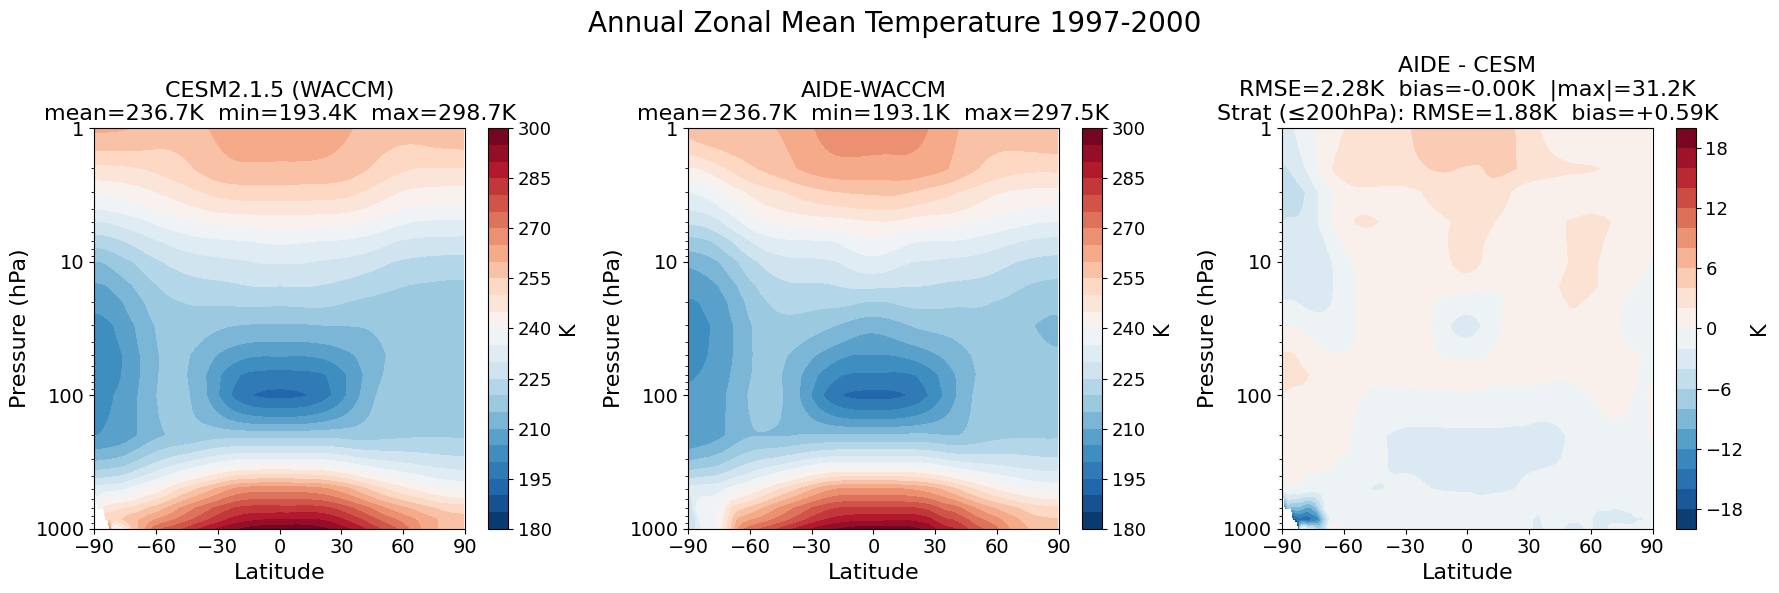

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Pressure levels and lats
plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats = np.linspace(-89.5, 89.5, 180)

# Compute stats for titles
diff = T_annual_zonal_aide - T_annual_zonal_cesm
rmse = np.sqrt(np.nanmean(diff**2))
bias = np.nanmean(diff)
max_err = np.nanmax(np.abs(diff))

# Stratosphere only (levels above 200 hPa, i.e. index 0:12)
strat_mask = plevs <= 200  # (17,) boolean
diff_strat = diff[strat_mask, :]
rmse_strat = np.sqrt(np.nanmean(diff_strat**2))
bias_strat = np.nanmean(diff_strat)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Common contour levels for T
levels = np.linspace(180, 300, 25)

# CESM
cf1 = axes[0].contourf(lats, plevs, T_annual_zonal_cesm, levels=levels, cmap='RdBu_r')
axes[0].set_title(f'CESM2.1.5 (WACCM)\nmean={np.nanmean(T_annual_zonal_cesm):.1f}K  '
                  f'min={np.nanmin(T_annual_zonal_cesm):.1f}K  '
                  f'max={np.nanmax(T_annual_zonal_cesm):.1f}K', fontsize=16)

# AIDE-WACCM
cf2 = axes[1].contourf(lats, plevs, T_annual_zonal_aide, levels=levels, cmap='RdBu_r')
axes[1].set_title(f'AIDE-WACCM\nmean={np.nanmean(T_annual_zonal_aide):.1f}K  '
                  f'min={np.nanmin(T_annual_zonal_aide):.1f}K  '
                  f'max={np.nanmax(T_annual_zonal_aide):.1f}K', fontsize=16)

# Difference
diff_levels = np.linspace(-20, 20, 21)
cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
axes[2].set_title(f'AIDE - CESM\n'
                  f'RMSE={rmse:.2f}K  bias={bias:+.2f}K  |max|={max_err:.1f}K\n'
                  f'Strat (≤200hPa): RMSE={rmse_strat:.2f}K  bias={bias_strat:+.2f}K', fontsize=16)

# Formatting for all panels
for ax in axes:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)', fontsize=16)
    ax.set_xlabel('Latitude', fontsize=16)
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.tick_params(axis='both', labelsize=14)

cbar1 = plt.colorbar(cf1, ax=axes[0], label='K')
cbar2 = plt.colorbar(cf2, ax=axes[1], label='K')
cbar3 = plt.colorbar(cf3, ax=axes[2], label='K')
for cbar in [cbar1, cbar2, cbar3]:
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('K', fontsize=15)

plt.suptitle('Annual Zonal Mean Temperature 1997-2000', fontsize=20)
plt.tight_layout()
#plt.savefig('zonal_mean_T_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

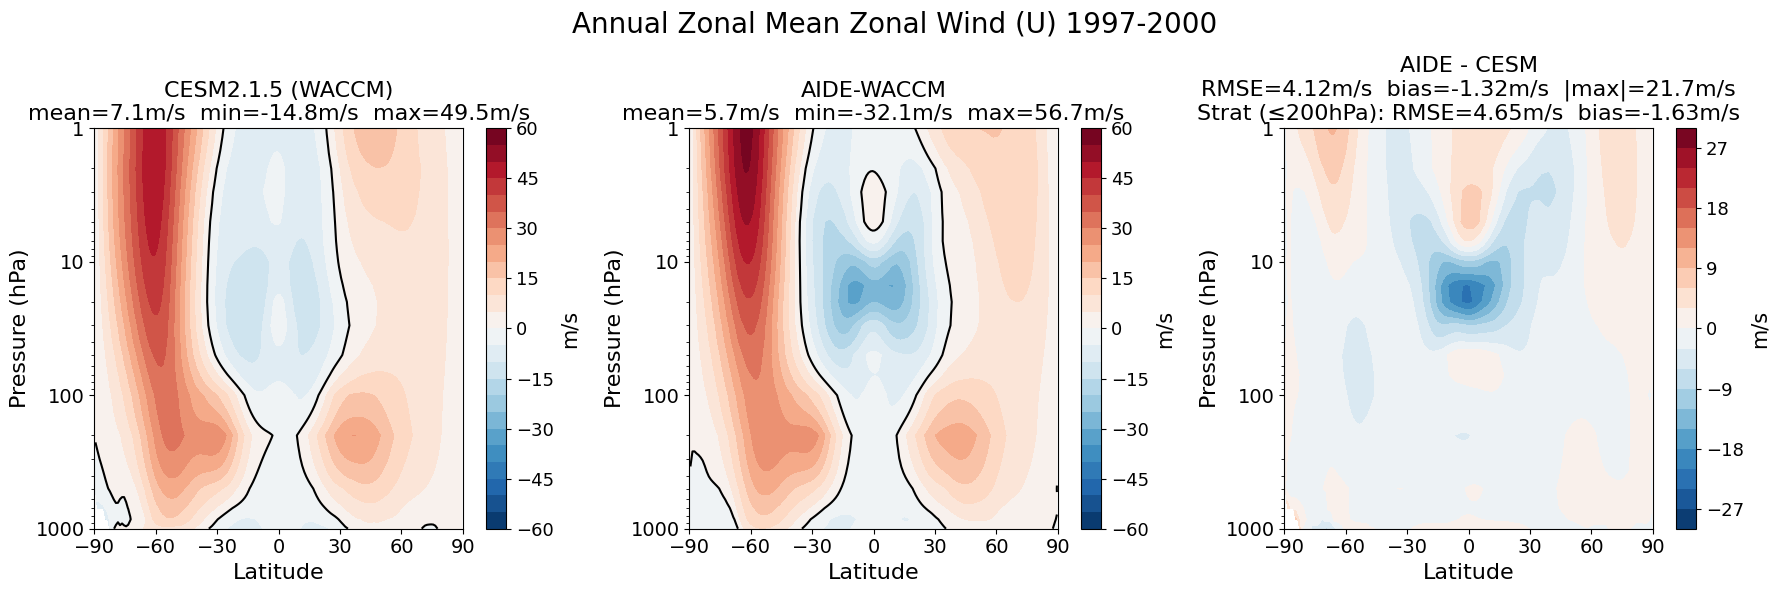

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Pressure levels and lats
plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats = np.linspace(-89.5, 89.5, 180)

# Compute stats for titles
diff = U_annual_zonal_aide - U_annual_zonal_cesm
rmse = np.sqrt(np.nanmean(diff**2))
bias = np.nanmean(diff)
max_err = np.nanmax(np.abs(diff))

# Stratosphere only
strat_mask = plevs <= 200
diff_strat = diff[strat_mask, :]
rmse_strat = np.sqrt(np.nanmean(diff_strat**2))
bias_strat = np.nanmean(diff_strat)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Common contour levels for U
levels = np.linspace(-60, 60, 25)

# CESM
cf1 = axes[0].contourf(lats, plevs, U_annual_zonal_cesm, levels=levels, cmap='RdBu_r')
axes[0].set_title(f'CESM2.1.5 (WACCM)\nmean={np.nanmean(U_annual_zonal_cesm):.1f}m/s  '
                  f'min={np.nanmin(U_annual_zonal_cesm):.1f}m/s  '
                  f'max={np.nanmax(U_annual_zonal_cesm):.1f}m/s', fontsize=16)

# AIDE-WACCM
cf2 = axes[1].contourf(lats, plevs, U_annual_zonal_aide, levels=levels, cmap='RdBu_r')
axes[1].set_title(f'AIDE-WACCM\nmean={np.nanmean(U_annual_zonal_aide):.1f}m/s  '
                  f'min={np.nanmin(U_annual_zonal_aide):.1f}m/s  '
                  f'max={np.nanmax(U_annual_zonal_aide):.1f}m/s', fontsize=16)

axes[0].contour(lats, plevs, U_annual_zonal_cesm, levels=[0], colors='black', linewidths=1.5)
axes[1].contour(lats, plevs, U_annual_zonal_aide, levels=[0], colors='black', linewidths=1.5)

# Difference
diff_levels = np.linspace(-30, 30, 21)
cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
axes[2].set_title(f'AIDE - CESM\n'
                  f'RMSE={rmse:.2f}m/s  bias={bias:+.2f}m/s  |max|={max_err:.1f}m/s\n'
                  f'Strat (≤200hPa): RMSE={rmse_strat:.2f}m/s  bias={bias_strat:+.2f}m/s', fontsize=16)

# Formatting for all panels
for ax in axes:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)', fontsize=16)
    ax.set_xlabel('Latitude', fontsize=16)
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.tick_params(axis='both', labelsize=14)
    #ax.axhline(y=200, color='k', linestyle='--', linewidth=0.5)  # tropopause guide

cbar1 = plt.colorbar(cf1, ax=axes[0], label='m/s')
cbar2 = plt.colorbar(cf2, ax=axes[1], label='m/s')
cbar3 = plt.colorbar(cf3, ax=axes[2], label='m/s')
for cbar in [cbar1, cbar2, cbar3]:
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('m/s', fontsize=15)

plt.suptitle('Annual Zonal Mean Zonal Wind (U) 1997-2000', fontsize=20)
plt.tight_layout()
plt.show()

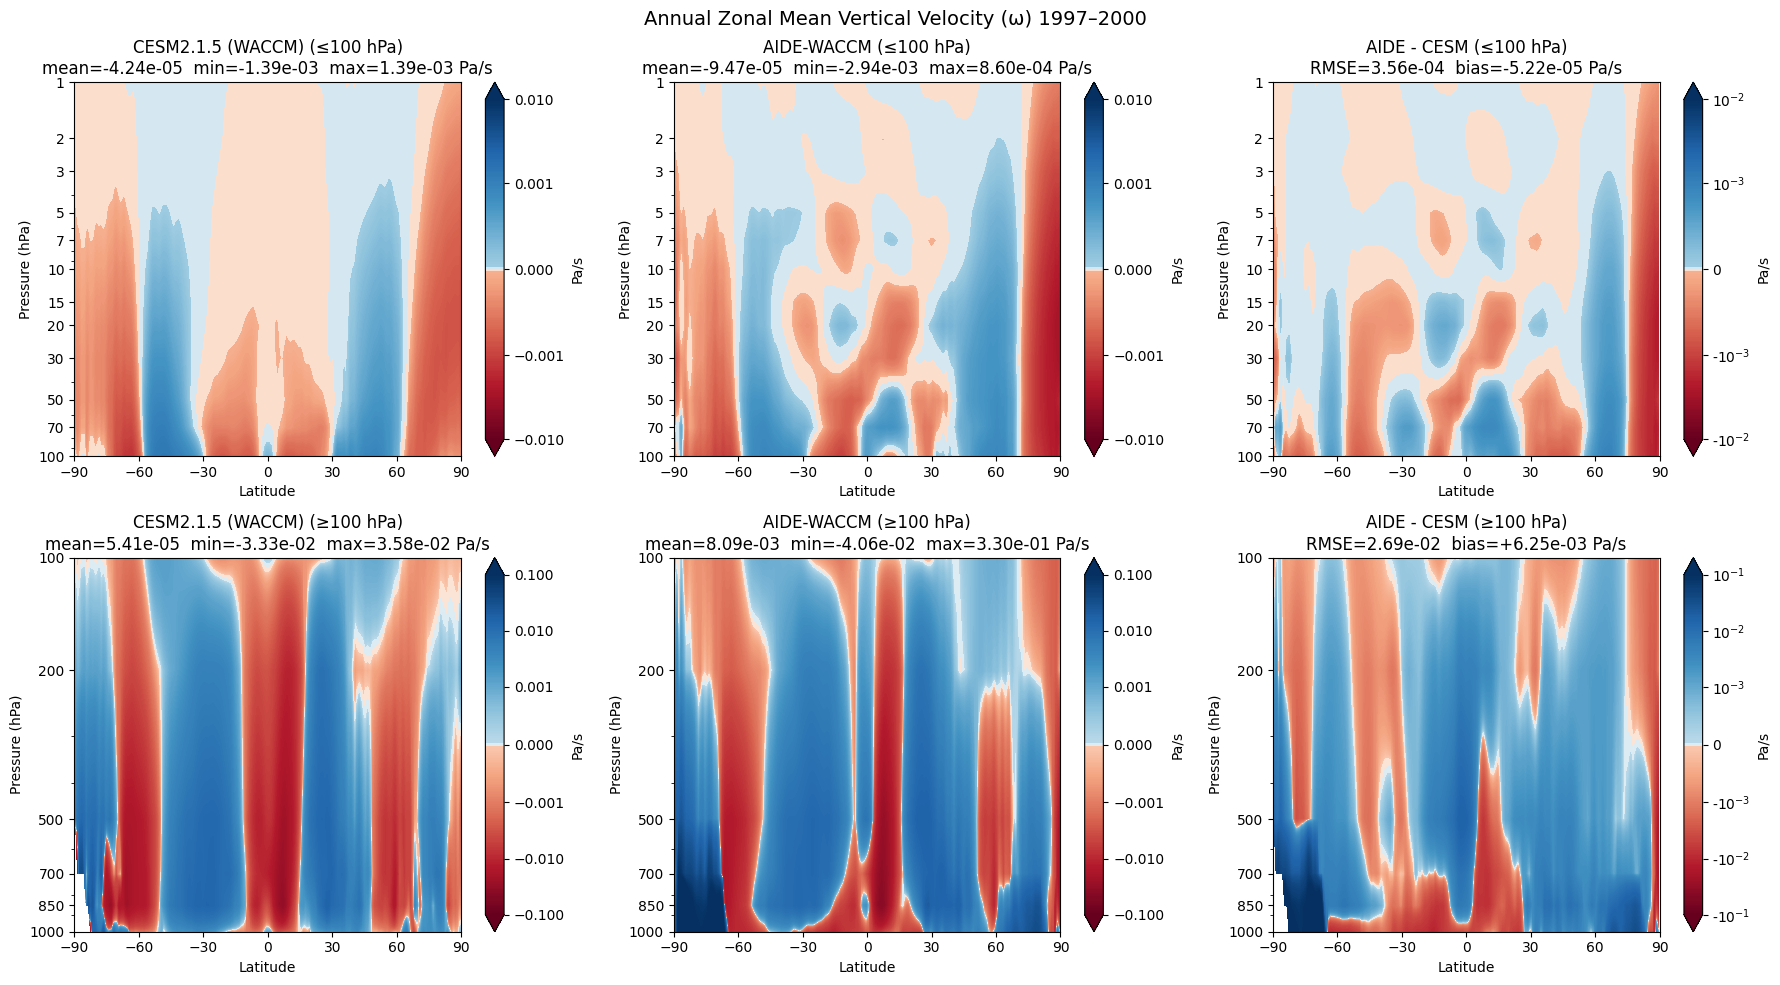

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats = np.linspace(-89.5, 89.5, 180)

diff = w_annual_zonal_aide - w_annual_zonal_cesm

# Split by pressure
strat_mask = plevs <= 100
trop_mask  = plevs >= 100

plevs_strat = plevs[strat_mask]
plevs_trop  = plevs[trop_mask]

# -----------------------------------------------------------------------------
# Symlog settings
# -----------------------------------------------------------------------------

linthresh = 1e-4
vmax_strat = 0.01
vmax_trop  = 0.1

norm_strat = mcolors.SymLogNorm(
    linthresh=linthresh,
    vmin=-vmax_strat,
    vmax=vmax_strat,
    base=10
)

norm_trop = mcolors.SymLogNorm(
    linthresh=linthresh,
    vmin=-vmax_trop,
    vmax=vmax_trop,
    base=10
)

# -----------------------------------------------------------------------------
# Many contour levels
# -----------------------------------------------------------------------------

def make_levels(vmax, linthresh, n_per_side=100):
    pos = np.logspace(
        np.log10(linthresh),
        np.log10(vmax),
        n_per_side
    )

    levels = np.concatenate([
        -pos[::-1],
        [0],
        pos
    ])

    return levels

# -----------------------------------------------------------------------------
# Colorbar ticks
# -----------------------------------------------------------------------------

def symlog_ticks(vmax, linthresh):
    exp_min = int(np.floor(np.log10(linthresh))) + 1  # skip the linthresh decade
    exp_max = int(np.floor(np.log10(vmax)))
    pos = [10.0**e for e in range(exp_min, exp_max + 1)]
    neg = [-x for x in reversed(pos)]
    return neg + [0] + pos

def symlog_fmt(x, pos):
    if np.isclose(x, 0):
        return "0"

    sign = "-" if x < 0 else ""
    exp = int(np.round(np.log10(abs(x))))

    return rf"{sign}$10^{{{exp}}}$"

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (w_annual_zonal_cesm, 'CESM2.1.5 (WACCM)'),
    (w_annual_zonal_aide, 'AIDE-WACCM'),
    (diff,                'AIDE - CESM'),
]

for col, (data, title) in enumerate(datasets):

    is_diff = (col == 2)

    # -------------------------------------------------------------------------
    # Row 0: Stratosphere
    # -------------------------------------------------------------------------

    ax = axes[0, col]

    vmax = vmax_strat
    norm = norm_strat

    cf = ax.contourf(
        lats,
        plevs_strat,
        data[strat_mask, :],
        levels=make_levels(vmax, linthresh, n_per_side=100),
        cmap='RdBu',
        norm=norm,
        extend='both'
    )

    cbar = plt.colorbar(cf, ax=ax, label='Pa/s')
    cbar.set_ticks(symlog_ticks(vmax, linthresh))
    cbar.ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(symlog_fmt)
    )

    ax.set_yscale('log')
    ax.invert_yaxis()

    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])

    ax.yaxis.set_major_locator(ticker.FixedLocator(plevs_strat))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x)}')
    )
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    if is_diff:
        ax.set_title(
            f'{title} (≤100 hPa)\n'
            f'RMSE={np.sqrt(np.nanmean(data[strat_mask,:]**2)):.2e}  '
            f'bias={np.nanmean(data[strat_mask,:]):+.2e} Pa/s'
        )
    else:
        d = data[strat_mask, :]
        ax.set_title(
            f'{title} (≤100 hPa)\n'
            f'mean={np.nanmean(d):.2e}  '
            f'min={np.nanmin(d):.2e}  '
            f'max={np.nanmax(d):.2e} Pa/s'
        )

    # -------------------------------------------------------------------------
    # Row 1: Troposphere
    # -------------------------------------------------------------------------

    ax = axes[1, col]

    vmax = vmax_trop
    norm = norm_trop

    cf = ax.contourf(
        lats,
        plevs_trop,
        data[trop_mask, :],
        levels=make_levels(vmax, linthresh, n_per_side=100),
        cmap='RdBu',
        norm=norm,
        extend='both'
    )

    cbar = plt.colorbar(cf, ax=ax, label='Pa/s')
    cbar.set_ticks(symlog_ticks(vmax, linthresh))
    cbar.ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(symlog_fmt)
    )

    ax.set_yscale('log')
    ax.invert_yaxis()

    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])

    ax.yaxis.set_major_locator(ticker.FixedLocator(plevs_trop))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x)}')
    )
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    if is_diff:
        ax.set_title(
            f'{title} (≥100 hPa)\n'
            f'RMSE={np.sqrt(np.nanmean(data[trop_mask,:]**2)):.2e}  '
            f'bias={np.nanmean(data[trop_mask,:]):+.2e} Pa/s'
        )
    else:
        d = data[trop_mask, :]
        ax.set_title(
            f'{title} (≥100 hPa)\n'
            f'mean={np.nanmean(d):.2e}  '
            f'min={np.nanmin(d):.2e}  '
            f'max={np.nanmax(d):.2e} Pa/s'
        )

plt.suptitle(
    'Annual Zonal Mean Vertical Velocity (ω) 1997–2000',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Seasonal Biases

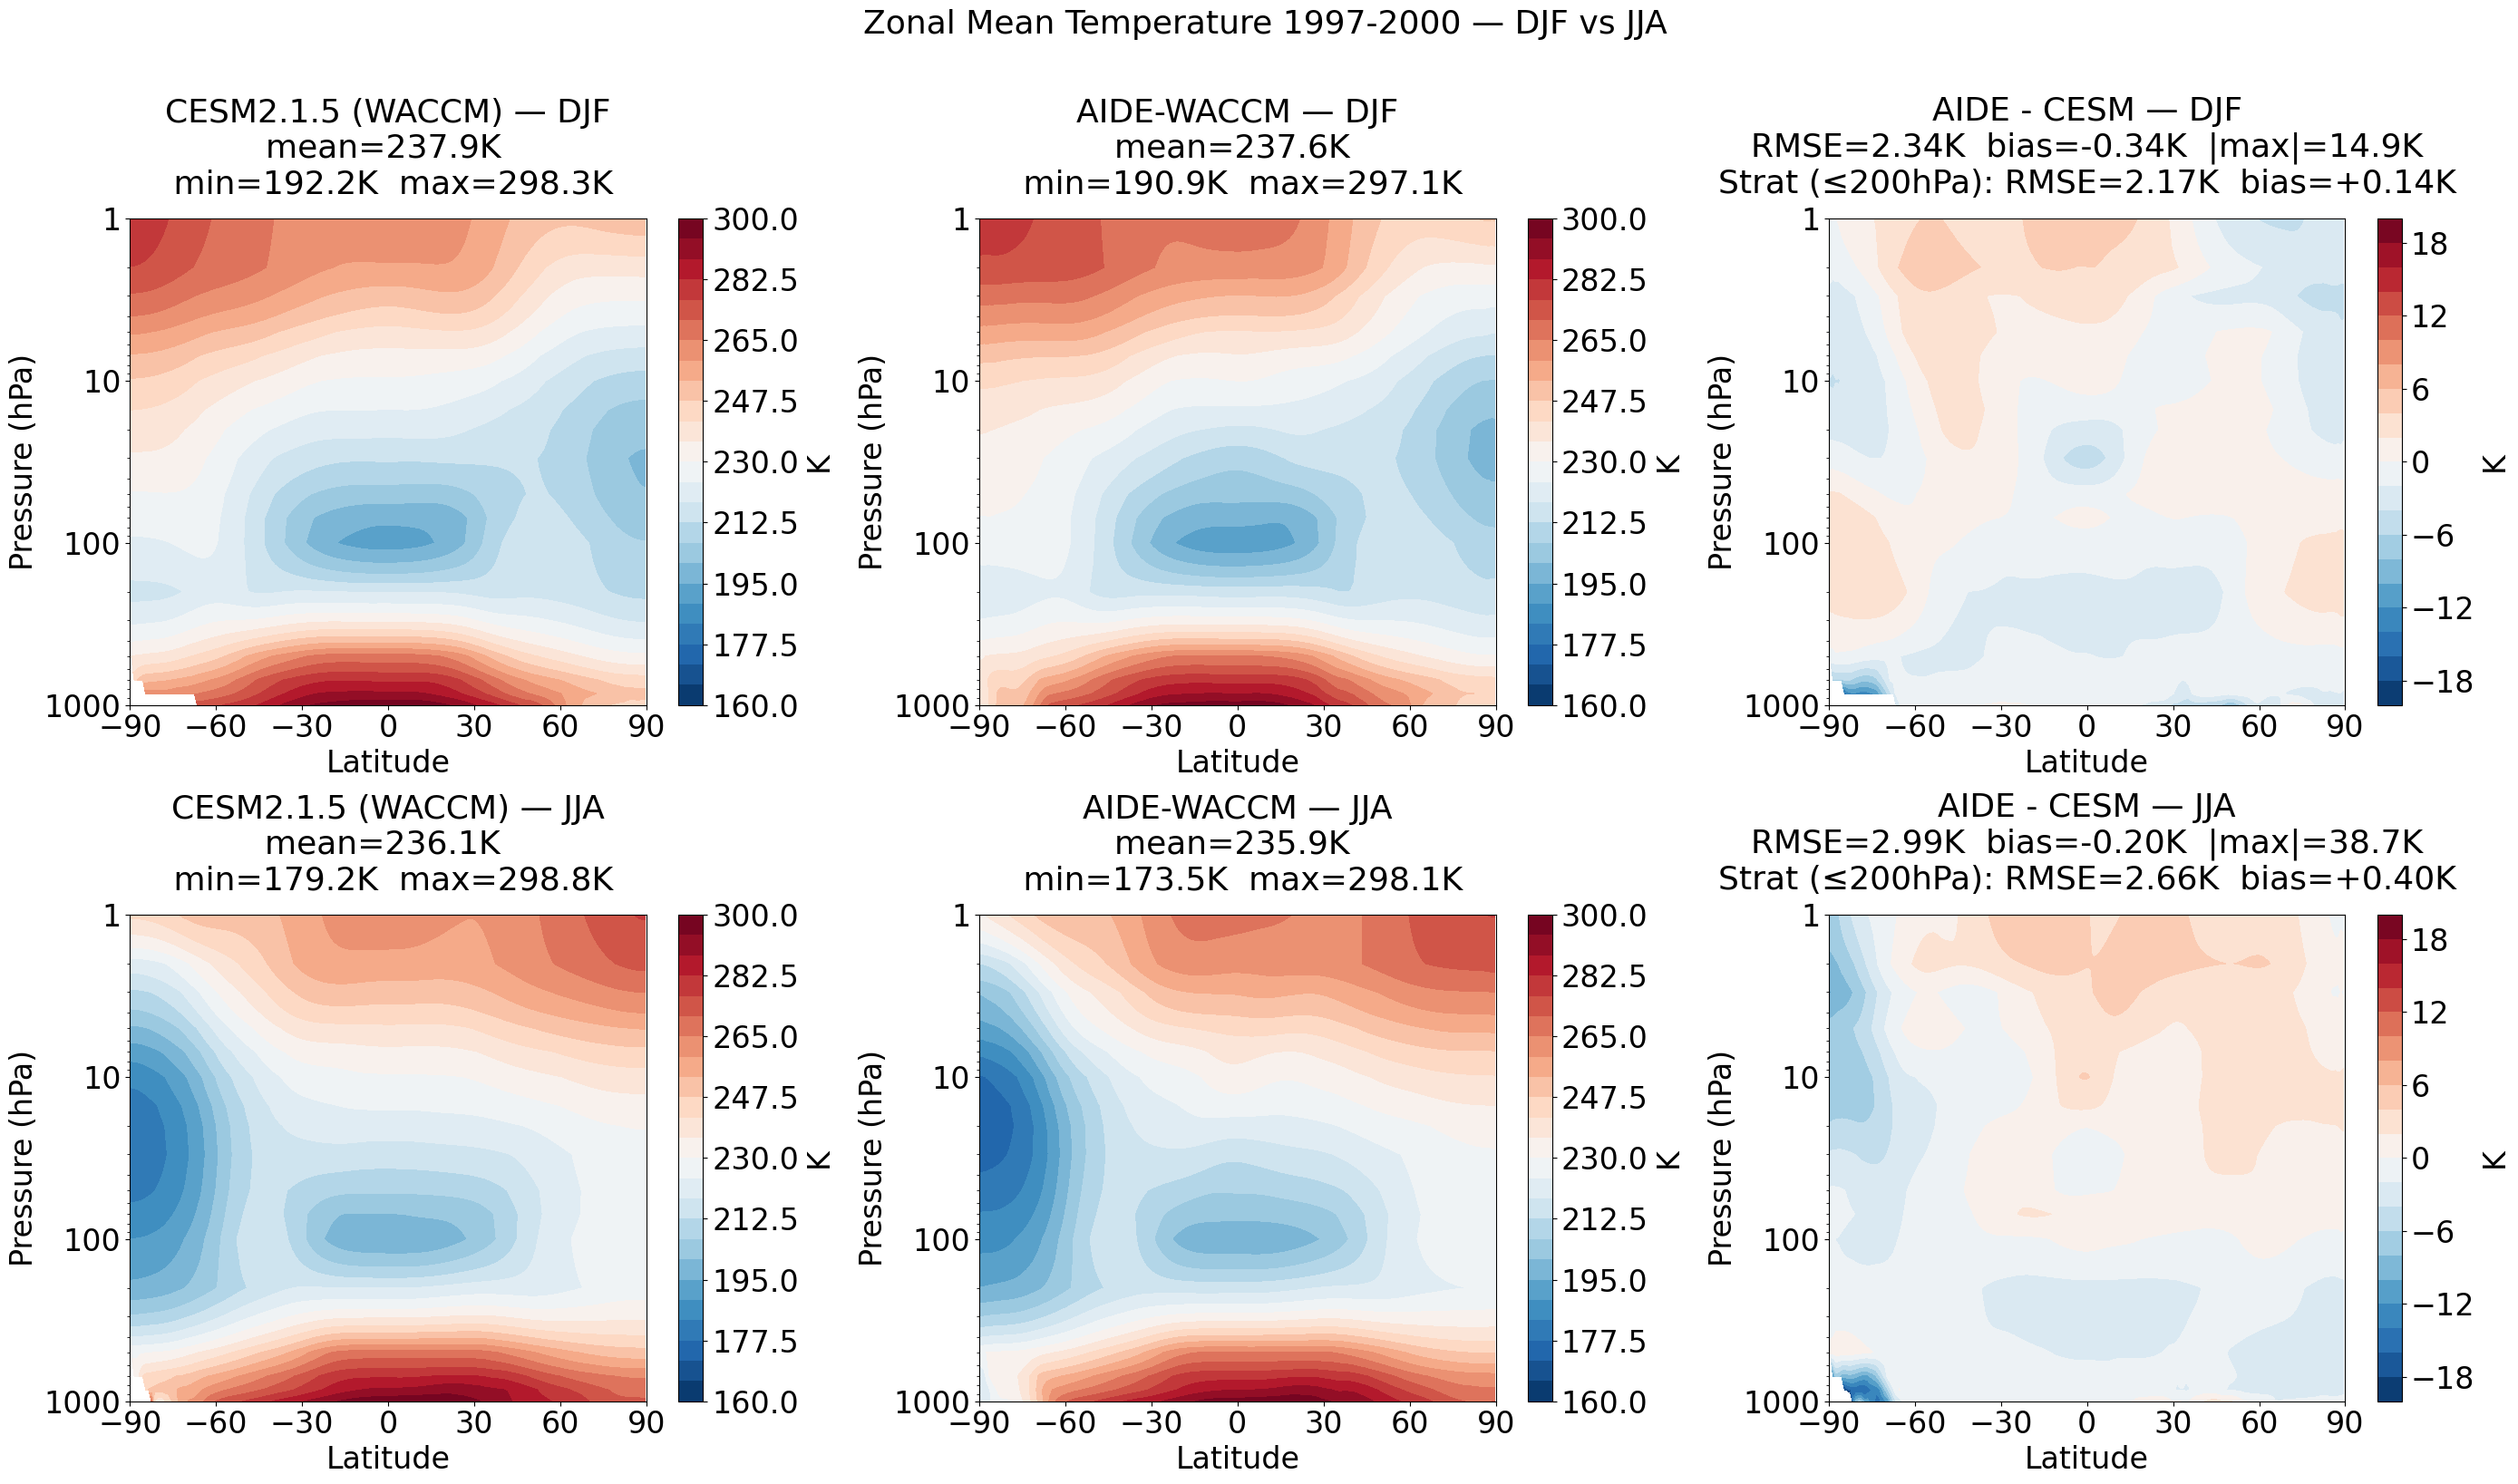

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)
strat_mask = plevs <= 200

# ── poster font sizes ───────────────────────────────────────────────────────
TITLE_FS    = 26
LABEL_FS    = 24
TICK_FS     = 24
CBAR_FS     = 24
SUPTITLE_FS = 26

def compute_stats(aide, cesm):
    diff       = aide - cesm
    rmse       = np.sqrt(np.nanmean(diff**2))
    bias       = np.nanmean(diff)
    max_err    = np.nanmax(np.abs(diff))
    diff_strat = diff[strat_mask, :]
    rmse_strat = np.sqrt(np.nanmean(diff_strat**2))
    bias_strat = np.nanmean(diff_strat)
    return diff, rmse, bias, max_err, rmse_strat, bias_strat

def plot_row(axes, cesm, aide, season_label, levels, diff_levels):
    diff, rmse, bias, max_err, rmse_strat, bias_strat = compute_stats(aide, cesm)

    cf1 = axes[0].contourf(lats, plevs, cesm, levels=levels, cmap='RdBu_r')
    axes[0].set_title(f'CESM2.1.5 (WACCM) — {season_label}\n'
                      f'mean={np.nanmean(cesm):.1f}K \n '
                      f'min={np.nanmin(cesm):.1f}K  '
                      f'max={np.nanmax(cesm):.1f}K',
                      fontsize=TITLE_FS, pad=20)

    cf2 = axes[1].contourf(lats, plevs, aide, levels=levels, cmap='RdBu_r')
    axes[1].set_title(f'AIDE-WACCM — {season_label}\n'
                      f'mean={np.nanmean(aide):.1f}K \n '
                      f'min={np.nanmin(aide):.1f}K  '
                      f'max={np.nanmax(aide):.1f}K',
                      fontsize=TITLE_FS, pad=20)

    cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
    axes[2].set_title(f'AIDE - CESM — {season_label}\n'
                      f'RMSE={rmse:.2f}K  bias={bias:+.2f}K  |max|={max_err:.1f}K\n'
                      f'Strat (≤200hPa): RMSE={rmse_strat:.2f}K  bias={bias_strat:+.2f}K',
                      fontsize=TITLE_FS, pad=20)

    for ax, cf, label in zip(axes, [cf1, cf2, cf3], ['K', 'K', 'K']):
        ax.set_yscale('log')
        ax.invert_yaxis()
        ax.set_ylabel('Pressure (hPa)', fontsize=LABEL_FS)
        ax.set_xlabel('Latitude', fontsize=LABEL_FS)
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.tick_params(axis='both', labelsize=TICK_FS)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        cbar = plt.colorbar(cf, ax=ax, label=label)
        cbar.set_label(label, fontsize=CBAR_FS)
        cbar.ax.tick_params(labelsize=TICK_FS)

    return cf1, cf2, cf3

# ── figure ─────────────────────────────────────────────────────────────────
levels      = np.linspace(160, 300, 25)
diff_levels = np.linspace(-20, 20, 21)

fig, axes = plt.subplots(2, 3, figsize=(28, 16))

plot_row(axes[0], T_DJF_zonal_cesm, T_DJF_zonal_aide, 'DJF', levels, diff_levels)
plot_row(axes[1], T_JJA_zonal_cesm, T_JJA_zonal_aide, 'JJA', levels, diff_levels)

plt.suptitle('Zonal Mean Temperature 1997-2000 — DJF vs JJA', fontsize=SUPTITLE_FS, y=1.02)
plt.tight_layout()
plt.savefig('./presentation_figs/zonal_temp_poster.png', dpi=300, bbox_inches='tight')
plt.show()

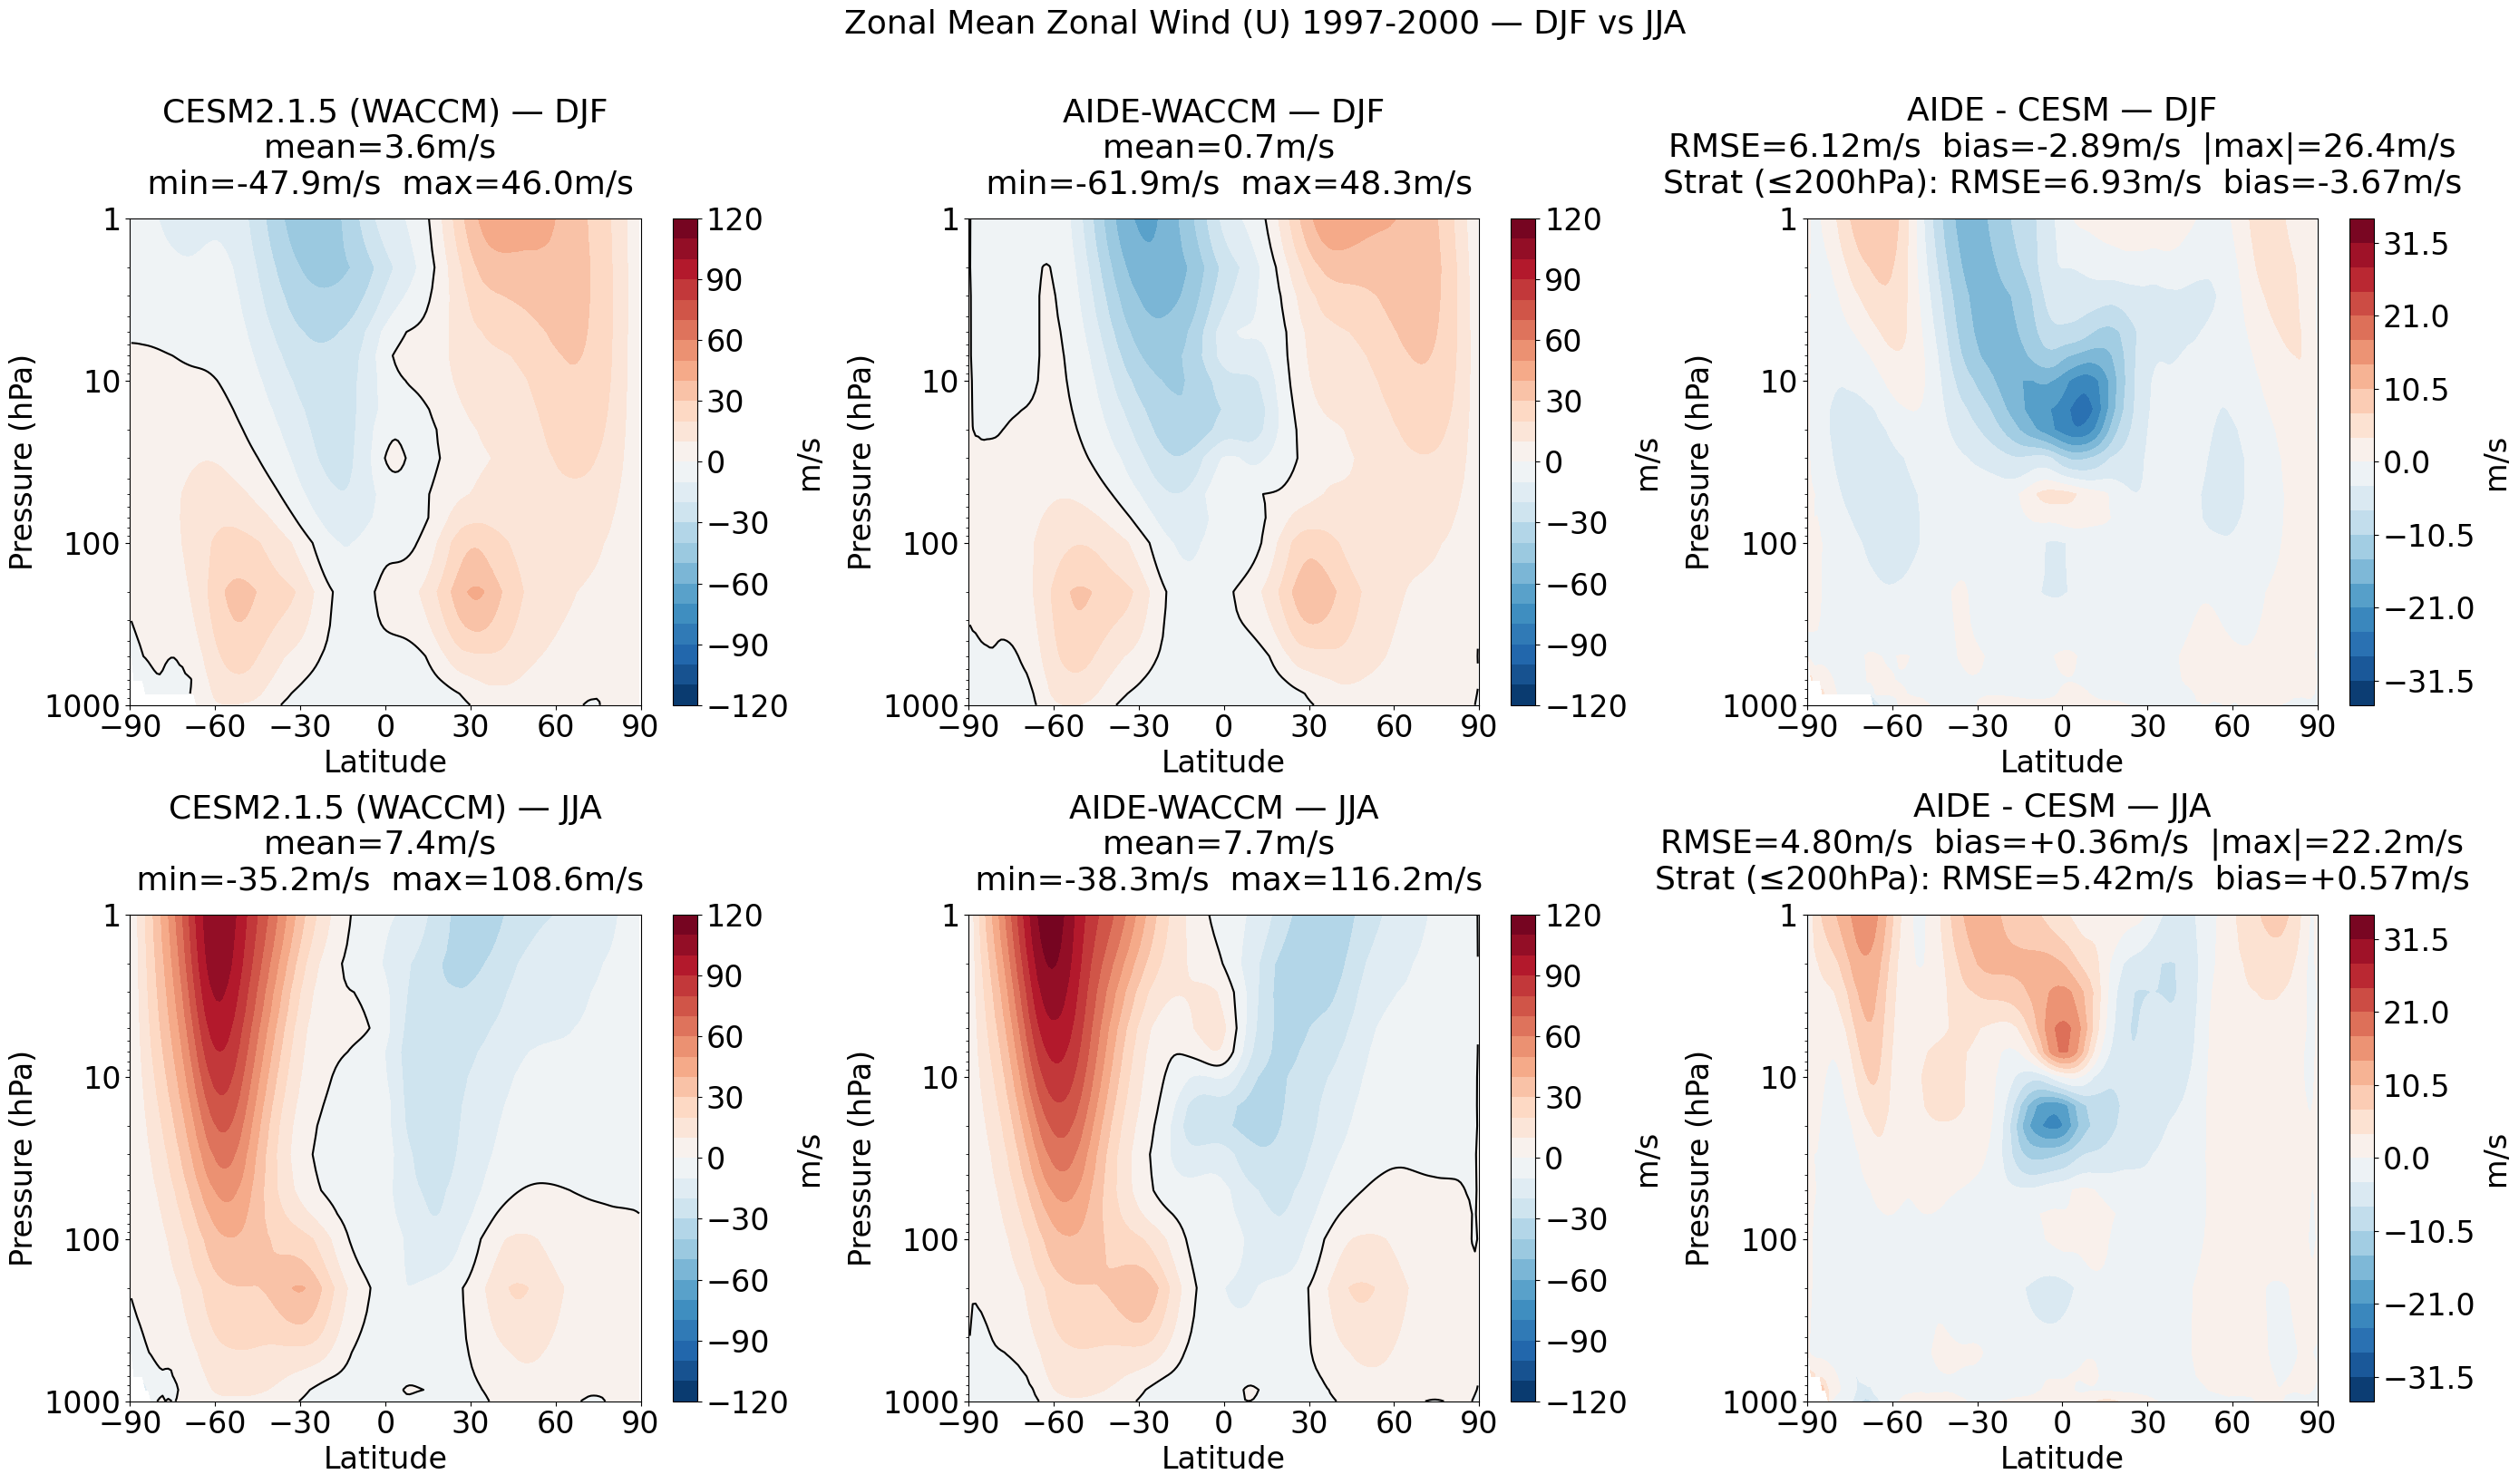

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)
strat_mask = plevs <= 200

# ── poster font sizes ───────────────────────────────────────────────────────
TITLE_FS    = 26
LABEL_FS    = 24
TICK_FS     = 24
CBAR_FS     = 24
SUPTITLE_FS = 26

def compute_stats_U(aide, cesm):
    diff       = aide - cesm
    rmse       = np.sqrt(np.nanmean(diff**2))
    bias       = np.nanmean(diff)
    max_err    = np.nanmax(np.abs(diff))
    diff_strat = diff[strat_mask, :]
    rmse_strat = np.sqrt(np.nanmean(diff_strat**2))
    bias_strat = np.nanmean(diff_strat)
    return diff, rmse, bias, max_err, rmse_strat, bias_strat

def plot_row_U(axes, cesm, aide, season_label, levels, diff_levels):
    diff, rmse, bias, max_err, rmse_strat, bias_strat = compute_stats_U(aide, cesm)

    cf1 = axes[0].contourf(lats, plevs, cesm, levels=levels, cmap='RdBu_r')
    axes[0].contour(lats, plevs, cesm, levels=[0], colors='black', linewidths=1.5)
    axes[0].set_title(f'CESM2.1.5 (WACCM) — {season_label}\n'
                      f'mean={np.nanmean(cesm):.1f}m/s \n '
                      f'min={np.nanmin(cesm):.1f}m/s  '
                      f'max={np.nanmax(cesm):.1f}m/s',
                      fontsize=TITLE_FS, pad = 20)

    cf2 = axes[1].contourf(lats, plevs, aide, levels=levels, cmap='RdBu_r')
    axes[1].contour(lats, plevs, aide, levels=[0], colors='black', linewidths=1.5)
    axes[1].set_title(f'AIDE-WACCM — {season_label}\n'
                      f'mean={np.nanmean(aide):.1f}m/s \n '
                      f'min={np.nanmin(aide):.1f}m/s  '
                      f'max={np.nanmax(aide):.1f}m/s',
                      fontsize=TITLE_FS, pad = 20)

    cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
    axes[2].set_title(f'AIDE - CESM — {season_label}\n'
                      f'RMSE={rmse:.2f}m/s  bias={bias:+.2f}m/s  |max|={max_err:.1f}m/s\n'
                      f'Strat (≤200hPa): RMSE={rmse_strat:.2f}m/s  bias={bias_strat:+.2f}m/s',
                      fontsize=TITLE_FS, pad = 20)

    for ax, cf, label in zip(axes, [cf1, cf2, cf3], ['m/s', 'm/s', 'm/s']):
        ax.set_yscale('log')
        ax.invert_yaxis()
        ax.set_ylabel('Pressure (hPa)', fontsize=LABEL_FS)
        ax.set_xlabel('Latitude', fontsize=LABEL_FS)
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.tick_params(axis='both', labelsize=TICK_FS)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        cbar = plt.colorbar(cf, ax=ax, label=label)
        cbar.set_label(label, fontsize=CBAR_FS)
        cbar.ax.tick_params(labelsize=TICK_FS)

# ── figure ─────────────────────────────────────────────────────────────────
levels      = np.linspace(-120, 120, 25)
diff_levels = np.linspace(-35, 35, 21)

fig, axes = plt.subplots(2, 3, figsize=(28, 16))

plot_row_U(axes[0], U_DJF_zonal_cesm, U_DJF_zonal_aide, 'DJF', levels, diff_levels)
plot_row_U(axes[1], U_JJA_zonal_cesm, U_JJA_zonal_aide, 'JJA', levels, diff_levels)

plt.suptitle('Zonal Mean Zonal Wind (U) 1997-2000 — DJF vs JJA', fontsize=SUPTITLE_FS, y = 1.02)
plt.tight_layout()
plt.savefig('./presentation_figs/zonal_wind_poster.png', dpi=300, bbox_inches='tight')
plt.show()

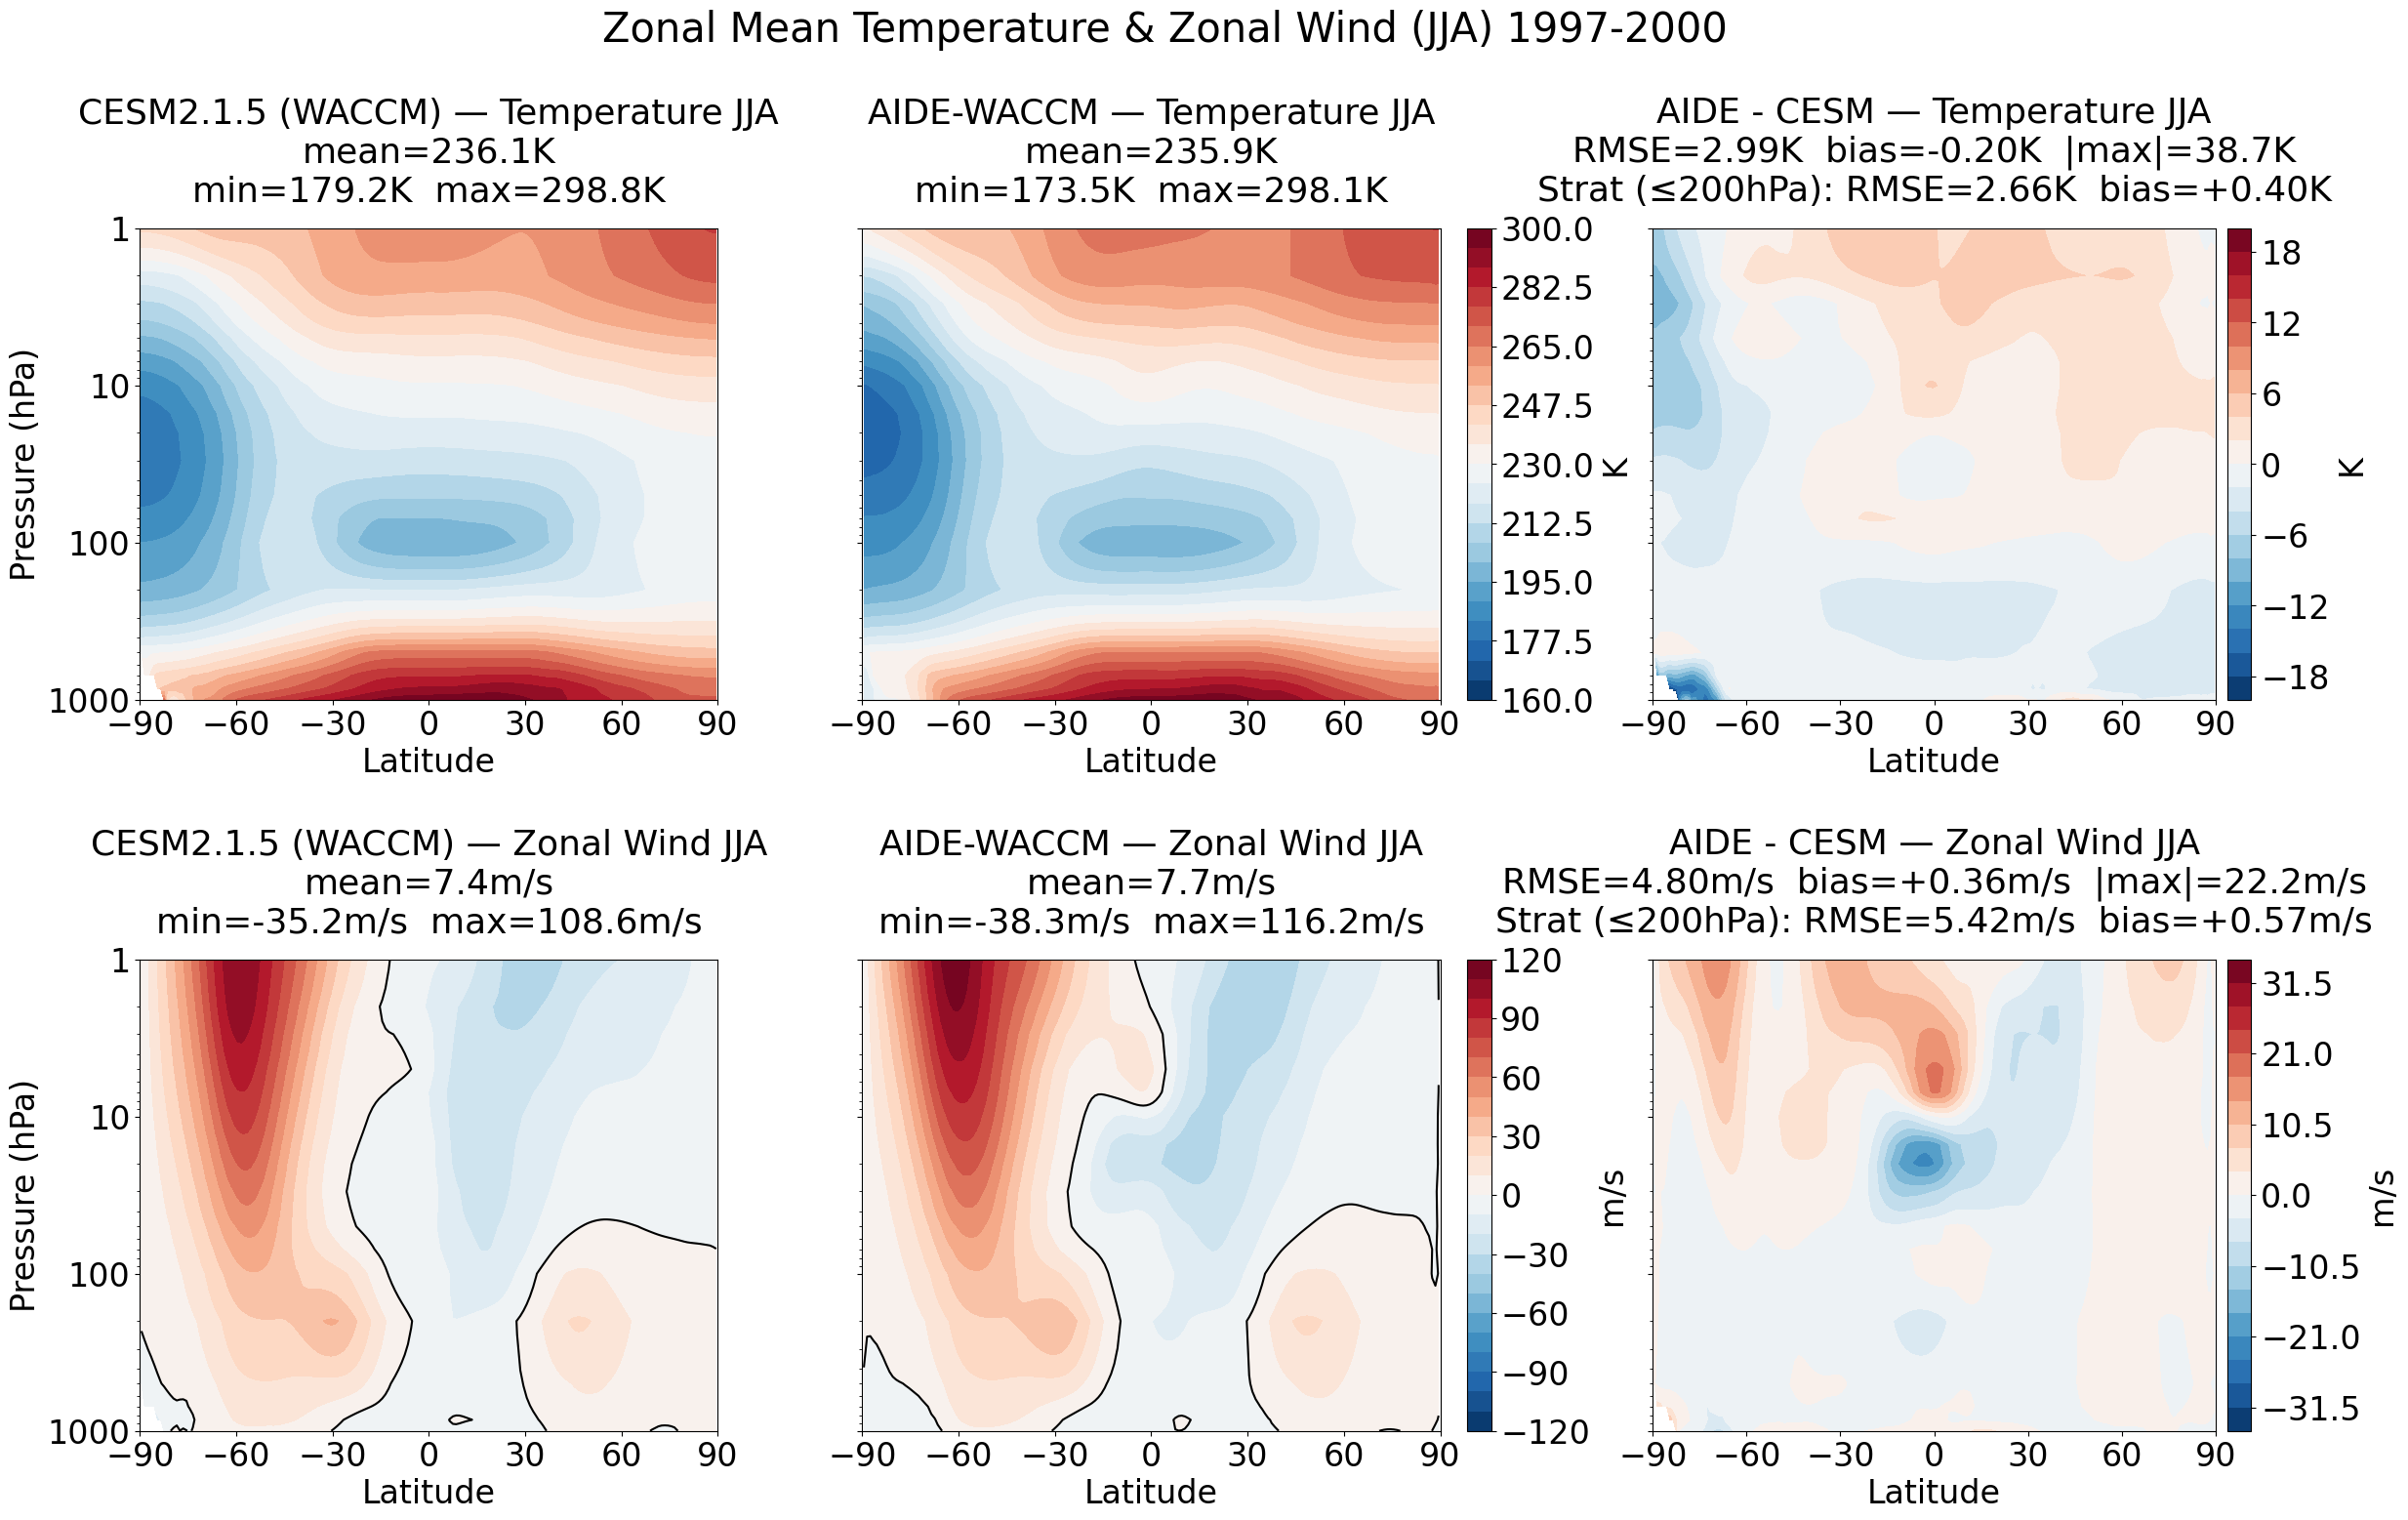

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)
strat_mask = plevs <= 200

# ── poster font sizes ───────────────────────────────────────────────────────
TITLE_FS    = 26
LABEL_FS    = 24
TICK_FS     = 24
CBAR_FS     = 24
SUPTITLE_FS = 30

def compute_stats(aide, cesm):
    diff       = aide - cesm
    rmse       = np.sqrt(np.nanmean(diff**2))
    bias       = np.nanmean(diff)
    max_err    = np.nanmax(np.abs(diff))
    diff_strat = diff[strat_mask, :]
    rmse_strat = np.sqrt(np.nanmean(diff_strat**2))
    bias_strat = np.nanmean(diff_strat)
    return diff, rmse, bias, max_err, rmse_strat, bias_strat

# ── figure ──────────────────────────────────────────────────────────────────
T_levels      = np.linspace(160, 300, 25)
T_diff_levels = np.linspace(-20, 20, 21)
U_levels      = np.linspace(-120, 120, 25)
U_diff_levels = np.linspace(-35, 35, 21)

fig, axes = plt.subplots(2, 3, figsize=(28, 16), sharey='row')

# ── row 0: Temperature JJA ──────────────────────────────────────────────────
T_diff, T_rmse, T_bias, T_max, T_rmse_s, T_bias_s = compute_stats(T_JJA_zonal_aide, T_JJA_zonal_cesm)

cf_T1 = axes[0,0].contourf(lats, plevs, T_JJA_zonal_cesm, levels=T_levels, cmap='RdBu_r')
axes[0,0].set_title(f'CESM2.1.5 (WACCM) — Temperature JJA\n'
                    f'mean={np.nanmean(T_JJA_zonal_cesm):.1f}K\n'
                    f'min={np.nanmin(T_JJA_zonal_cesm):.1f}K  '
                    f'max={np.nanmax(T_JJA_zonal_cesm):.1f}K',
                    fontsize=TITLE_FS, pad=20)

cf_T2 = axes[0,1].contourf(lats, plevs, T_JJA_zonal_aide, levels=T_levels, cmap='RdBu_r')
axes[0,1].set_title(f'AIDE-WACCM — Temperature JJA\n'
                    f'mean={np.nanmean(T_JJA_zonal_aide):.1f}K\n'
                    f'min={np.nanmin(T_JJA_zonal_aide):.1f}K  '
                    f'max={np.nanmax(T_JJA_zonal_aide):.1f}K',
                    fontsize=TITLE_FS, pad=20)

cf_T3 = axes[0,2].contourf(lats, plevs, T_diff, levels=T_diff_levels, cmap='RdBu_r')
axes[0,2].set_title(f'AIDE - CESM — Temperature JJA\n'
                    f'RMSE={T_rmse:.2f}K  bias={T_bias:+.2f}K  |max|={T_max:.1f}K\n'
                    f'Strat (≤200hPa): RMSE={T_rmse_s:.2f}K  bias={T_bias_s:+.2f}K',
                    fontsize=TITLE_FS, pad=20)

# ── row 1: Zonal Wind JJA ───────────────────────────────────────────────────
U_diff, U_rmse, U_bias, U_max, U_rmse_s, U_bias_s = compute_stats(U_JJA_zonal_aide, U_JJA_zonal_cesm)

cf_U1 = axes[1,0].contourf(lats, plevs, U_JJA_zonal_cesm, levels=U_levels, cmap='RdBu_r')
axes[1,0].contour(lats, plevs, U_JJA_zonal_cesm, levels=[0], colors='black', linewidths=1.5)
axes[1,0].set_title(f'CESM2.1.5 (WACCM) — Zonal Wind JJA\n'
                    f'mean={np.nanmean(U_JJA_zonal_cesm):.1f}m/s\n'
                    f'min={np.nanmin(U_JJA_zonal_cesm):.1f}m/s  '
                    f'max={np.nanmax(U_JJA_zonal_cesm):.1f}m/s',
                    fontsize=TITLE_FS, pad=20)

cf_U2 = axes[1,1].contourf(lats, plevs, U_JJA_zonal_aide, levels=U_levels, cmap='RdBu_r')
axes[1,1].contour(lats, plevs, U_JJA_zonal_aide, levels=[0], colors='black', linewidths=1.5)
axes[1,1].set_title(f'AIDE-WACCM — Zonal Wind JJA\n'
                    f'mean={np.nanmean(U_JJA_zonal_aide):.1f}m/s\n'
                    f'min={np.nanmin(U_JJA_zonal_aide):.1f}m/s  '
                    f'max={np.nanmax(U_JJA_zonal_aide):.1f}m/s',
                    fontsize=TITLE_FS, pad=20)

cf_U3 = axes[1,2].contourf(lats, plevs, U_diff, levels=U_diff_levels, cmap='RdBu_r')
axes[1,2].set_title(f'AIDE - CESM — Zonal Wind JJA\n'
                    f'RMSE={U_rmse:.2f}m/s  bias={U_bias:+.2f}m/s  |max|={U_max:.1f}m/s\n'
                    f'Strat (≤200hPa): RMSE={U_rmse_s:.2f}m/s  bias={U_bias_s:+.2f}m/s',
                    fontsize=TITLE_FS, pad=20)

# ── axis formatting (NO per-panel colorbars) ────────────────────────────────
# ── axis formatting (NO per-panel colorbars) ────────────────────────────────
for row in range(2):
    for col, ax in enumerate(axes[row]):
        ax.set_yscale('log')
        ax.set_ylim([1000, 1])
        ax.set_xlabel('Latitude', fontsize=LABEL_FS)
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.tick_params(axis='both', labelsize=TICK_FS)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        if col == 0:
            ax.set_ylabel('Pressure (hPa)', fontsize=LABEL_FS)

# ── set spacing BEFORE colorbars so they attach to final positions ──────────
fig.subplots_adjust(wspace=0.25, hspace=0.55)

# ── one colorbar per panel-group ────────────────────────────────────────────
cbar_T = fig.colorbar(cf_T1, ax=axes[0, :2].tolist(), location='right',
                      fraction=0.025, pad=0.02)
cbar_T.set_label('K', fontsize=CBAR_FS); cbar_T.ax.tick_params(labelsize=TICK_FS)

cbar_Td = fig.colorbar(cf_T3, ax=axes[0, 2], location='right',
                       fraction=0.05, pad=0.02)
cbar_Td.set_label('K', fontsize=CBAR_FS); cbar_Td.ax.tick_params(labelsize=TICK_FS)

cbar_U = fig.colorbar(cf_U1, ax=axes[1, :2].tolist(), location='right',
                      fraction=0.025, pad=0.02)
cbar_U.set_label('m/s', fontsize=CBAR_FS); cbar_U.ax.tick_params(labelsize=TICK_FS)

cbar_Ud = fig.colorbar(cf_U3, ax=axes[1, 2], location='right',
                       fraction=0.05, pad=0.02)
cbar_Ud.set_label('m/s', fontsize=CBAR_FS); cbar_Ud.ax.tick_params(labelsize=TICK_FS)

plt.suptitle('Zonal Mean Temperature & Zonal Wind (JJA) 1997-2000', fontsize=SUPTITLE_FS, y=1.02)
plt.savefig('./presentation_figs/zonal_temp_wind_JJA_poster.png', dpi=300, bbox_inches='tight')
plt.show()

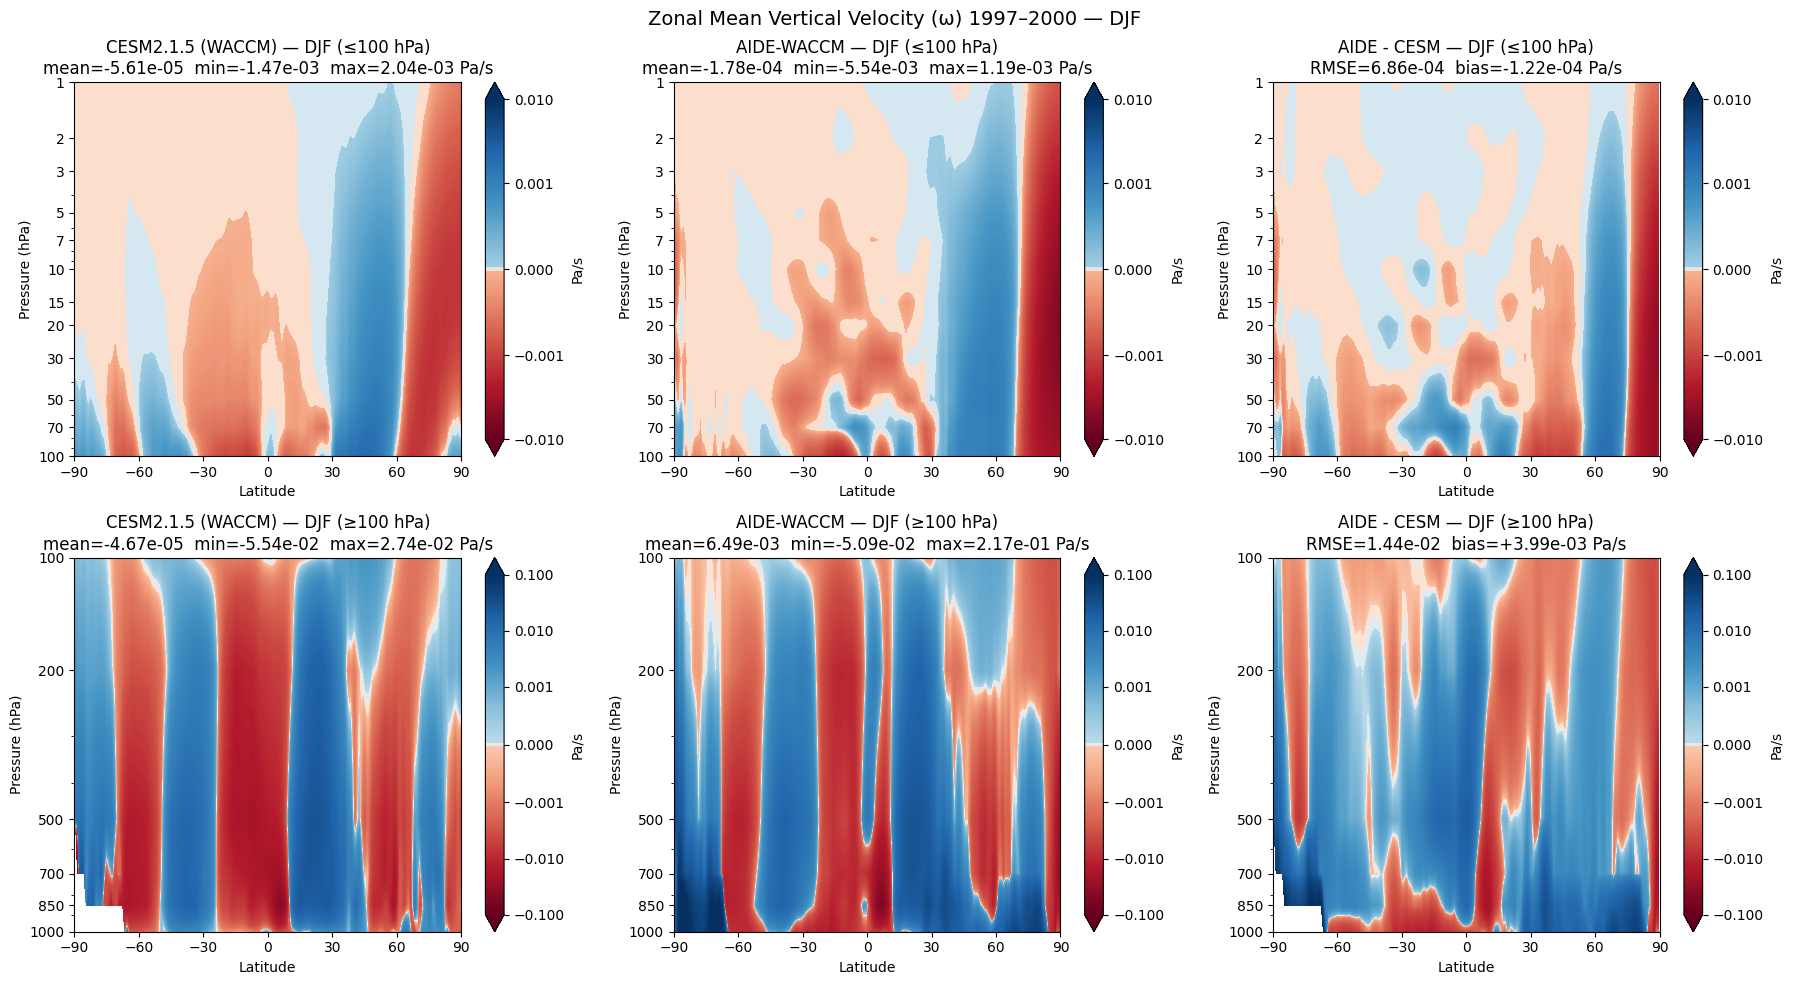

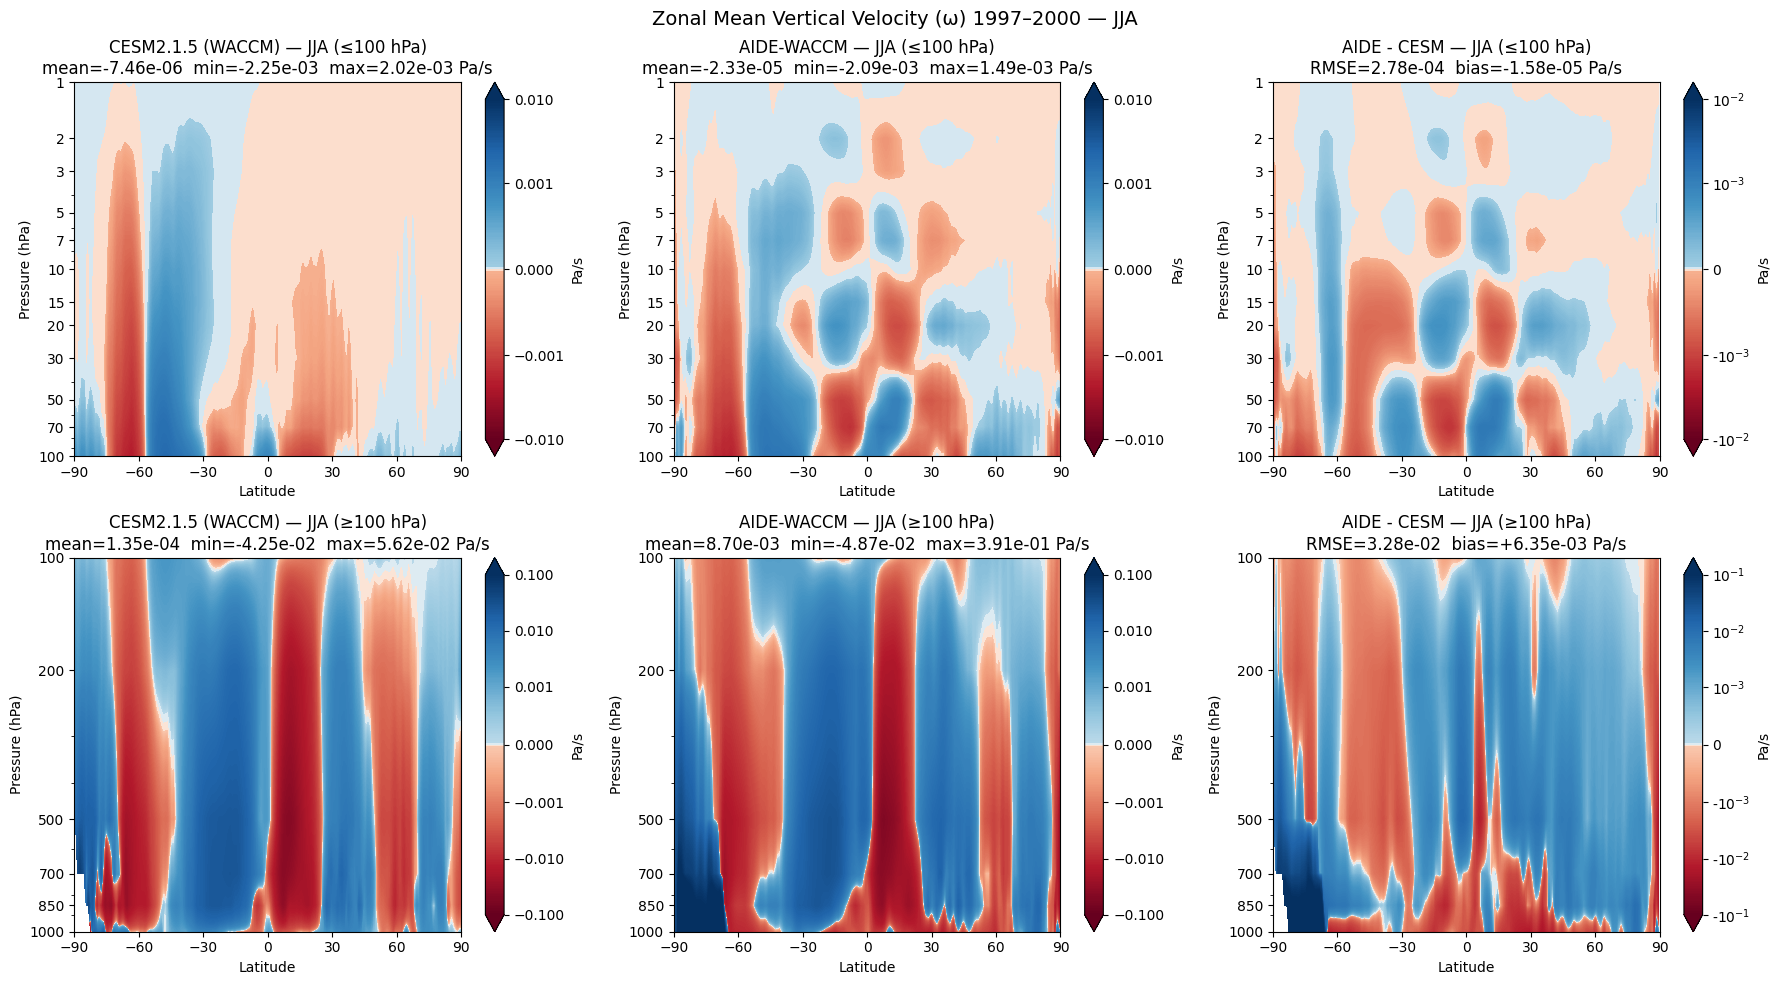

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)

# Split by pressure
strat_mask  = plevs <= 100
trop_mask   = plevs >= 100
plevs_strat = plevs[strat_mask]
plevs_trop  = plevs[trop_mask]

# -----------------------------------------------------------------------------
# Symlog settings
# -----------------------------------------------------------------------------

linthresh  = 1e-4
vmax_strat = 0.01
vmax_trop  = 0.1

norm_strat = mcolors.SymLogNorm(linthresh=linthresh, vmin=-vmax_strat, vmax=vmax_strat, base=10)
norm_trop  = mcolors.SymLogNorm(linthresh=linthresh, vmin=-vmax_trop,  vmax=vmax_trop,  base=10)

def make_levels(vmax, linthresh, n_per_side=100):
    pos = np.logspace(np.log10(linthresh), np.log10(vmax), n_per_side)
    return np.concatenate([-pos[::-1], [0], pos])

def symlog_ticks(vmax, linthresh):
    exp_min = int(np.floor(np.log10(linthresh))) + 1
    exp_max = int(np.floor(np.log10(vmax)))
    pos = [10.0**e for e in range(exp_min, exp_max + 1)]
    neg = [-x for x in reversed(pos)]
    return neg + [0] + pos

def symlog_fmt(x, pos):
    if np.isclose(x, 0):
        return "0"
    sign = "-" if x < 0 else ""
    exp  = int(np.round(np.log10(abs(x))))
    return rf"{sign}$10^{{{exp}}}$"

def add_symlog_colorbar(cf, ax, vmax, linthresh):
    cbar = plt.colorbar(cf, ax=ax, label='Pa/s')
    cbar.set_ticks(symlog_ticks(vmax, linthresh))
    cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(symlog_fmt))
    return cbar

def format_ax(ax, plevs_fixed):
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.yaxis.set_major_locator(ticker.FixedLocator(plevs_fixed))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}'))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# -----------------------------------------------------------------------------
# Row plotting function
# -----------------------------------------------------------------------------

def plot_season(fig, axes, cesm, aide, season_label):
    """
    axes : (2, 3) array of Axes — row 0 = strat, row 1 = trop
    """
    diff = aide - cesm

    datasets = [
        (cesm, f'CESM2.1.5 (WACCM) — {season_label}'),
        (aide, f'AIDE-WACCM — {season_label}'),
        (diff, f'AIDE - CESM — {season_label}'),
    ]

    for col, (data, title) in enumerate(datasets):
        is_diff = (col == 2)

        # --- Stratosphere ---
        ax = axes[0, col]
        cf = ax.contourf(lats, plevs_strat, data[strat_mask, :],
                         levels=make_levels(vmax_strat, linthresh),
                         cmap='RdBu', norm=norm_strat, extend='both')
        format_ax(ax, plevs_strat)
        add_symlog_colorbar(cf, ax, vmax_strat, linthresh)

        if is_diff:
            d = data[strat_mask, :]
            ax.set_title(f'{title} (≤100 hPa)\n'
                         f'RMSE={np.sqrt(np.nanmean(d**2)):.2e}  '
                         f'bias={np.nanmean(d):+.2e} Pa/s')
        else:
            d = data[strat_mask, :]
            ax.set_title(f'{title} (≤100 hPa)\n'
                         f'mean={np.nanmean(d):.2e}  '
                         f'min={np.nanmin(d):.2e}  '
                         f'max={np.nanmax(d):.2e} Pa/s')

        # --- Troposphere ---
        ax = axes[1, col]
        cf = ax.contourf(lats, plevs_trop, data[trop_mask, :],
                         levels=make_levels(vmax_trop, linthresh),
                         cmap='RdBu', norm=norm_trop, extend='both')
        format_ax(ax, plevs_trop)
        add_symlog_colorbar(cf, ax, vmax_trop, linthresh)

        if is_diff:
            d = data[trop_mask, :]
            ax.set_title(f'{title} (≥100 hPa)\n'
                         f'RMSE={np.sqrt(np.nanmean(d**2)):.2e}  '
                         f'bias={np.nanmean(d):+.2e} Pa/s')
        else:
            d = data[trop_mask, :]
            ax.set_title(f'{title} (≥100 hPa)\n'
                         f'mean={np.nanmean(d):.2e}  '
                         f'min={np.nanmin(d):.2e}  '
                         f'max={np.nanmax(d):.2e} Pa/s')

# -----------------------------------------------------------------------------
# DJF figure
# -----------------------------------------------------------------------------

fig_djf, axes_djf = plt.subplots(2, 3, figsize=(18, 10))
plot_season(fig_djf, axes_djf, w_DJF_zonal_cesm, w_DJF_zonal_aide, 'DJF')
fig_djf.suptitle('Zonal Mean Vertical Velocity (ω) 1997–2000 — DJF', fontsize=14)
fig_djf.tight_layout()

# -----------------------------------------------------------------------------
# JJA figure
# -----------------------------------------------------------------------------

fig_jja, axes_jja = plt.subplots(2, 3, figsize=(18, 10))
plot_season(fig_jja, axes_jja, w_JJA_zonal_cesm, w_JJA_zonal_aide, 'JJA')
fig_jja.suptitle('Zonal Mean Vertical Velocity (ω) 1997–2000 — JJA', fontsize=14)
fig_jja.tight_layout()

plt.show()

## STD plots

In [36]:
print(f"CESM std min location:")
idx = np.nanargmin(T_std_zonal_cesm)
lev_idx, lat_idx = np.unravel_index(idx, T_std_zonal_cesm.shape)
print(f"  level={plevs[lev_idx]} hPa, lat={lats[lat_idx]:.1f}°, value={T_std_zonal_cesm[lev_idx, lat_idx]:.3f}K")   ##the min=0.0K in the title is misleading — 
                                                                                                                    ##it's likely picking up a near-zero value somewhere at the surface/topography boundary rather than a true zero std dev

CESM std min location:
  level=1000 hPa, lat=-82.5°, value=0.000K


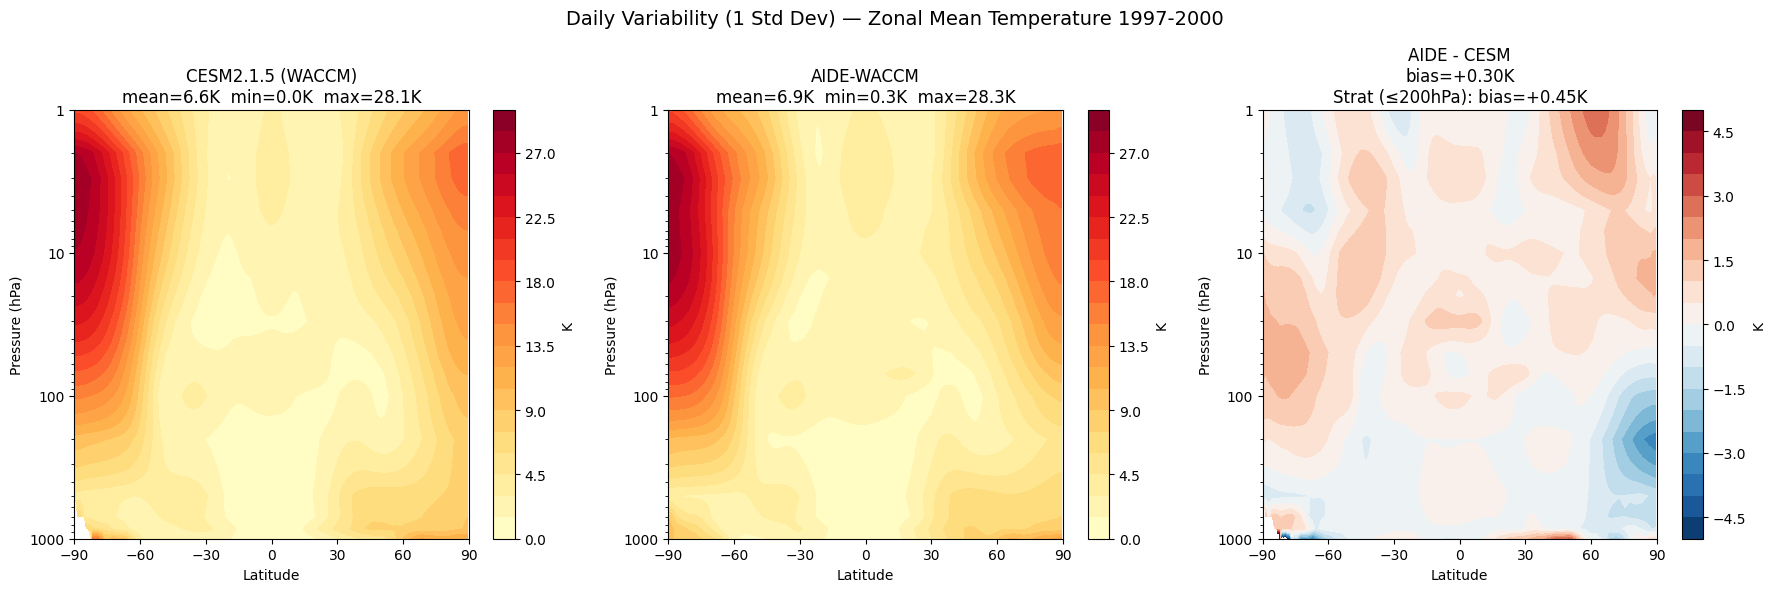

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)
strat_mask = plevs <= 200

# Compute stats on std diff
diff       = T_std_zonal_aide - T_std_zonal_cesm
bias       = np.nanmean(diff)
max_err    = np.nanmax(np.abs(diff))
diff_strat = diff[strat_mask, :]
bias_strat = np.nanmean(diff_strat)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Common contour levels for std
levels      = np.linspace(0, 30, 21)
diff_levels = np.linspace(-5, 5, 21)

# CESM
cf1 = axes[0].contourf(lats, plevs, T_std_zonal_cesm, levels=levels, cmap='YlOrRd')
axes[0].set_title(f'CESM2.1.5 (WACCM)\nmean={np.nanmean(T_std_zonal_cesm):.1f}K  '
                  f'min={np.nanmin(T_std_zonal_cesm):.1f}K  '
                  f'max={np.nanmax(T_std_zonal_cesm):.1f}K')

# AIDE-WACCM
cf2 = axes[1].contourf(lats, plevs, T_std_zonal_aide, levels=levels, cmap='YlOrRd')
axes[1].set_title(f'AIDE-WACCM\nmean={np.nanmean(T_std_zonal_aide):.1f}K  '
                  f'min={np.nanmin(T_std_zonal_aide):.1f}K  '
                  f'max={np.nanmax(T_std_zonal_aide):.1f}K')

# Difference
cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
axes[2].set_title(f'AIDE - CESM\n'
                  f'bias={bias:+.2f}K\n'
                  f'Strat (≤200hPa): bias={bias_strat:+.2f}K')

for ax in axes:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.colorbar(cf1, ax=axes[0], label='K')
plt.colorbar(cf2, ax=axes[1], label='K')
plt.colorbar(cf3, ax=axes[2], label='K')

plt.suptitle('Daily Variability (1 Std Dev) — Zonal Mean Temperature 1997-2000', fontsize=14)
plt.tight_layout()
plt.show()

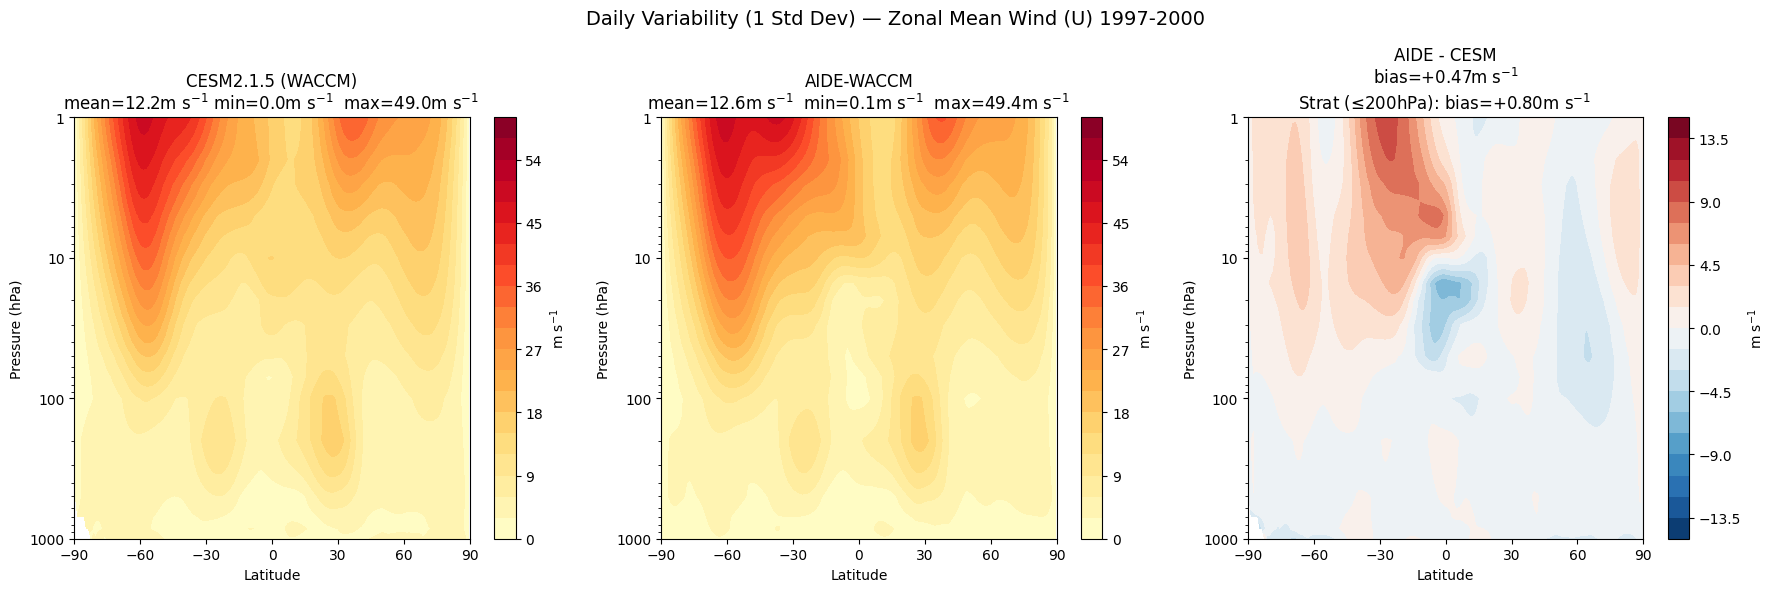

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)
strat_mask = plevs <= 200

# Compute stats on std diff
diff       = U_std_zonal_aide - U_std_zonal_cesm
bias       = np.nanmean(diff)
max_err    = np.nanmax(np.abs(diff))
diff_strat = diff[strat_mask, :]
bias_strat = np.nanmean(diff_strat)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Common contour levels for std
levels      = np.linspace(0, 60, 21)
diff_levels = np.linspace(-15, 15, 21)

# CESM
cf1 = axes[0].contourf(lats, plevs, U_std_zonal_cesm, levels=levels, cmap='YlOrRd')
axes[0].set_title(f'CESM2.1.5 (WACCM)\nmean={np.nanmean(U_std_zonal_cesm):.1f}m s$^{{-1}}$ '
                  f'min={np.nanmin(U_std_zonal_cesm):.1f}m s$^{{-1}}$  '
                  f'max={np.nanmax(U_std_zonal_cesm):.1f}m s$^{{-1}}$ ')

# AIDE-WACCM
cf2 = axes[1].contourf(lats, plevs, U_std_zonal_aide, levels=levels, cmap='YlOrRd')
axes[1].set_title(f'AIDE-WACCM\nmean={np.nanmean(U_std_zonal_aide):.1f}m s$^{{-1}}$  '
                  f'min={np.nanmin(U_std_zonal_aide):.1f}m s$^{{-1}}$  '
                  f'max={np.nanmax(U_std_zonal_aide):.1f}m s$^{{-1}}$ ')

# Difference
cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
axes[2].set_title(f'AIDE - CESM\n'
                  f'bias={bias:+.2f}m s$^{{-1}}$\n'
                  f'Strat (≤200hPa): bias={bias_strat:+.2f}m s$^{{-1}}$ ')

for ax in axes:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.colorbar(cf1, ax=axes[0], label='m s$^{-1}$')
plt.colorbar(cf2, ax=axes[1], label='m s$^{-1}$')
plt.colorbar(cf3, ax=axes[2], label='m s$^{-1}$')

plt.suptitle('Daily Variability (1 Std Dev) — Zonal Mean Wind (U) 1997-2000', fontsize=14)
plt.tight_layout()
plt.show()

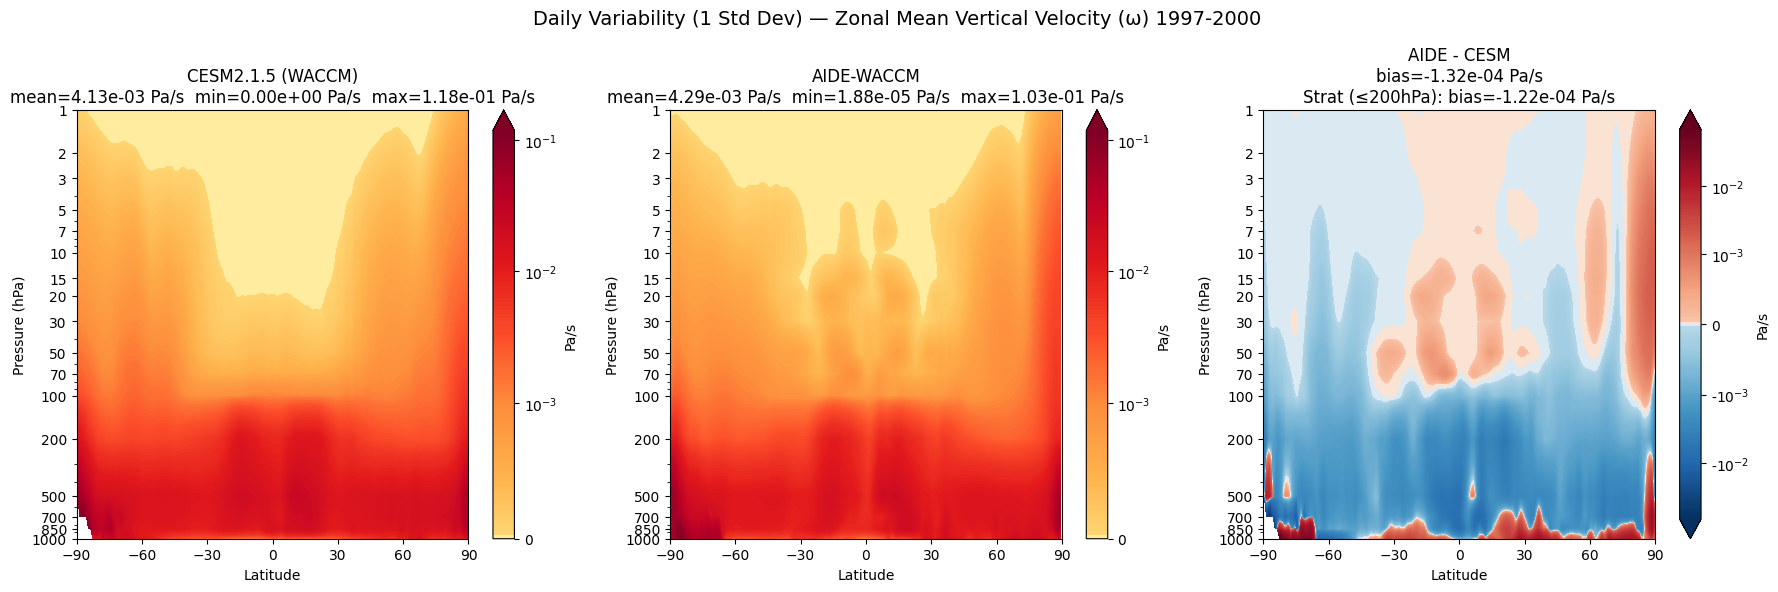

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)
strat_mask = plevs <= 200

# Compute stats
diff       = w_std_zonal_aide - w_std_zonal_cesm
bias       = np.nanmean(diff)
max_err    = np.nanmax(np.abs(diff))
diff_strat = diff[strat_mask, :]
bias_strat = np.nanmean(diff_strat)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Symlog norm for std fields (all positive, so just log is fine)
linthresh = 1e-4
vmax_std  = np.nanmax([w_std_zonal_cesm, w_std_zonal_aide])

norm_std = mcolors.SymLogNorm(linthresh=linthresh, vmin=0, vmax=vmax_std, base=10)

# For difference: signed symlog
diff_abs_max = np.nanmax(np.abs(diff))
norm_diff = mcolors.SymLogNorm(linthresh=linthresh, vmin=-diff_abs_max, vmax=diff_abs_max, base=10)

def symlog_ticks_pos(vmax, linthresh):
    """Ticks for a positive-only symlog colorbar."""
    exp_min = int(np.floor(np.log10(linthresh))) + 1
    exp_max = int(np.floor(np.log10(vmax)))
    return [0] + [10.0**e for e in range(exp_min, exp_max + 1)]

def symlog_ticks_signed(vmax, linthresh):
    exp_min = int(np.floor(np.log10(linthresh))) + 1
    exp_max = int(np.floor(np.log10(vmax)))
    pos = [10.0**e for e in range(exp_min, exp_max + 1)]
    return [-x for x in reversed(pos)] + [0] + pos

def symlog_fmt(x, pos):
    if np.isclose(x, 0):
        return "0"
    sign = "-" if x < 0 else ""
    exp  = int(np.round(np.log10(abs(x))))
    return rf"{sign}$10^{{{exp}}}$"

def make_levels_pos(vmax, linthresh, n=100):
    """Log-spaced levels from 0 to vmax."""
    pos = np.logspace(np.log10(linthresh), np.log10(vmax), n)
    return np.concatenate([[0], pos])

def make_levels_signed(vmax, linthresh, n=100):
    pos = np.logspace(np.log10(linthresh), np.log10(vmax), n)
    return np.concatenate([-pos[::-1], [0], pos])

# CESM
cf1 = axes[0].contourf(lats, plevs, w_std_zonal_cesm,
                        levels=make_levels_pos(vmax_std, linthresh),
                        cmap='YlOrRd', norm=norm_std, extend='max')
axes[0].set_title(f'CESM2.1.5 (WACCM)\n'
                  f'mean={np.nanmean(w_std_zonal_cesm):.2e} Pa/s  '
                  f'min={np.nanmin(w_std_zonal_cesm):.2e} Pa/s  '
                  f'max={np.nanmax(w_std_zonal_cesm):.2e} Pa/s')

# AIDE-WACCM
cf2 = axes[1].contourf(lats, plevs, w_std_zonal_aide,
                        levels=make_levels_pos(vmax_std, linthresh),
                        cmap='YlOrRd', norm=norm_std, extend='max')
axes[1].set_title(f'AIDE-WACCM\n'
                  f'mean={np.nanmean(w_std_zonal_aide):.2e} Pa/s  '
                  f'min={np.nanmin(w_std_zonal_aide):.2e} Pa/s  '
                  f'max={np.nanmax(w_std_zonal_aide):.2e} Pa/s')

# Difference
cf3 = axes[2].contourf(lats, plevs, diff,
                        levels=make_levels_signed(diff_abs_max, linthresh),
                        cmap='RdBu_r', norm=norm_diff, extend='both')
axes[2].set_title(f'AIDE - CESM\n'
                  f'bias={bias:+.2e} Pa/s\n'
                  f'Strat (≤200hPa): bias={bias_strat:+.2e} Pa/s')

# Formatting
for ax in axes:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.yaxis.set_major_locator(ticker.FixedLocator(plevs))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}'))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# Colorbars
cb1 = plt.colorbar(cf1, ax=axes[0], label='Pa/s')
cb1.set_ticks(symlog_ticks_pos(vmax_std, linthresh))
cb1.ax.yaxis.set_major_formatter(ticker.FuncFormatter(symlog_fmt))

cb2 = plt.colorbar(cf2, ax=axes[1], label='Pa/s')
cb2.set_ticks(symlog_ticks_pos(vmax_std, linthresh))
cb2.ax.yaxis.set_major_formatter(ticker.FuncFormatter(symlog_fmt))

cb3 = plt.colorbar(cf3, ax=axes[2], label='Pa/s')
cb3.set_ticks(symlog_ticks_signed(diff_abs_max, linthresh))
cb3.ax.yaxis.set_major_formatter(ticker.FuncFormatter(symlog_fmt))

plt.suptitle('Daily Variability (1 Std Dev) — Zonal Mean Vertical Velocity (ω) 1997-2000', fontsize=14)
plt.tight_layout()
plt.show()

## season breakdowns - std

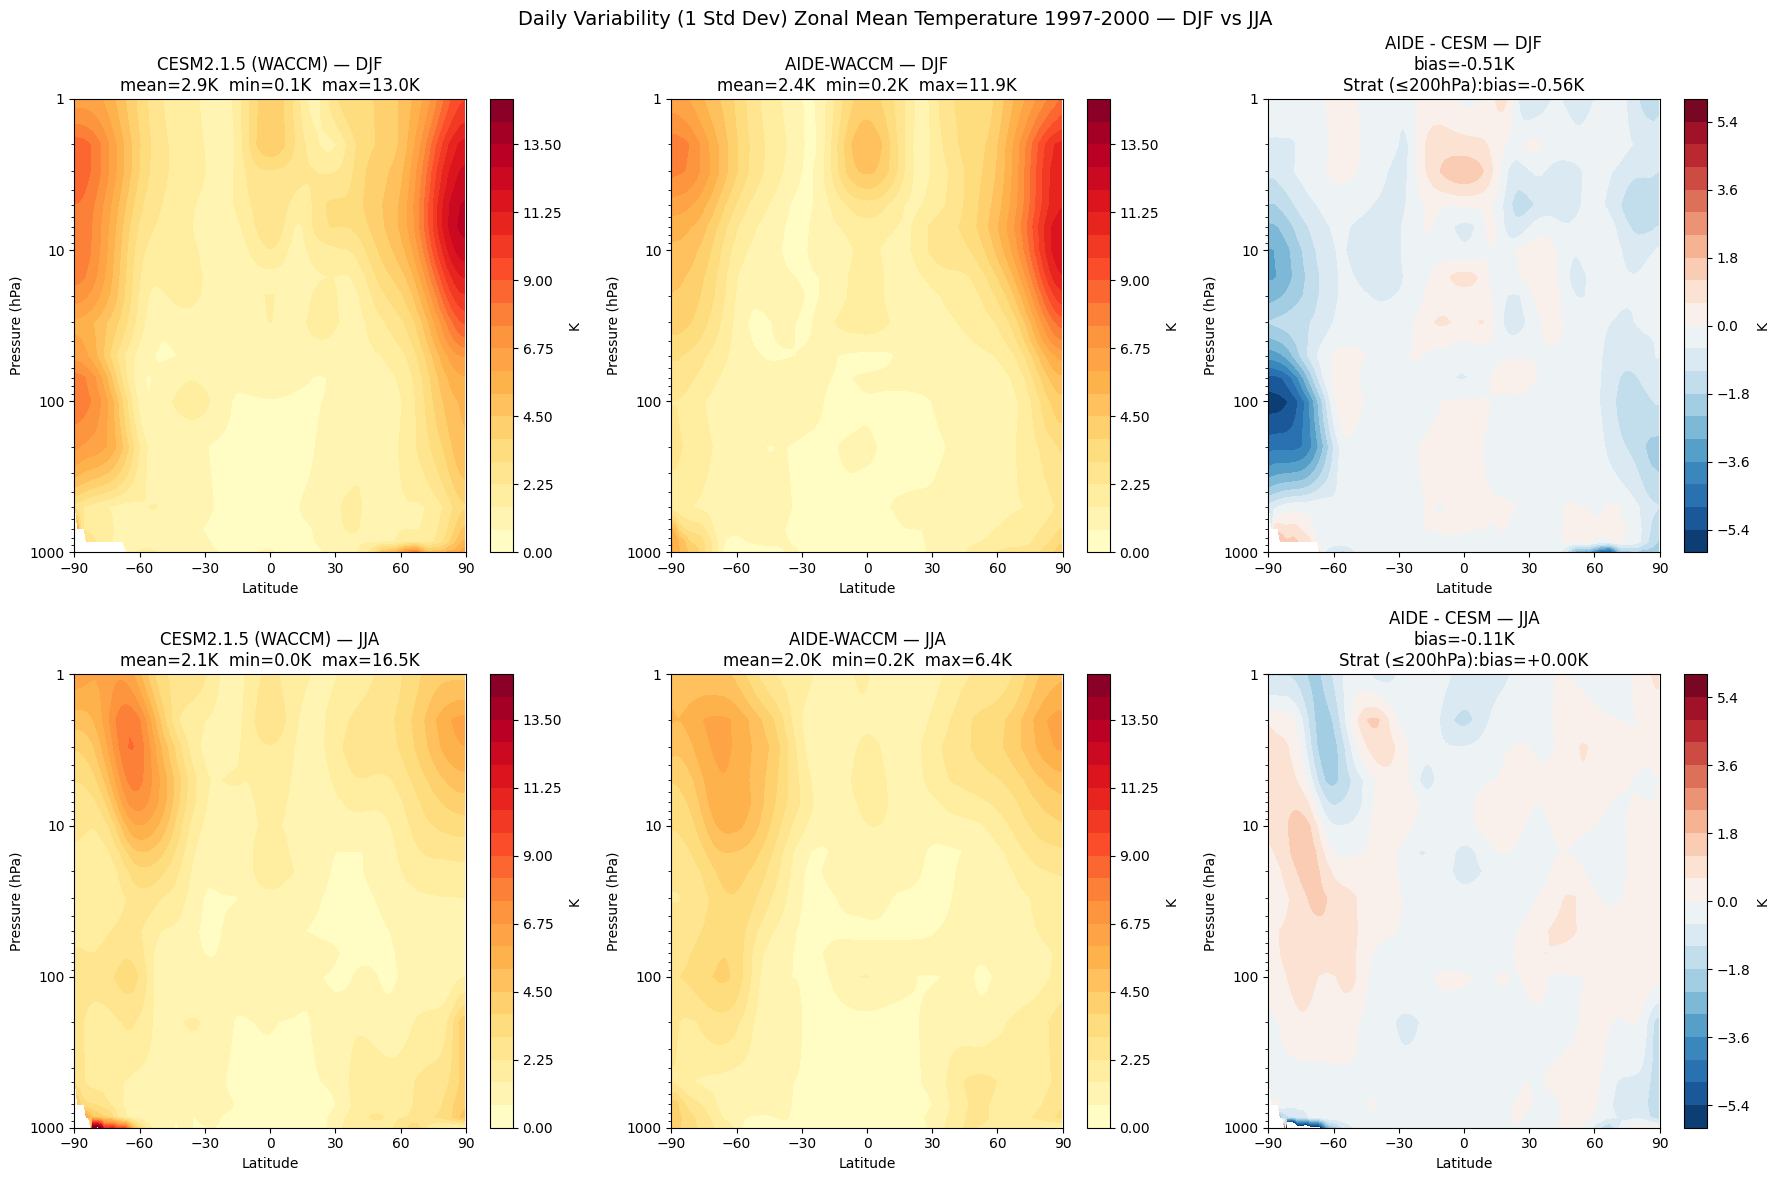

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
lats  = np.linspace(-89.5, 89.5, 180)
strat_mask = plevs <= 200

def compute_stats(aide, cesm):
    diff       = aide - cesm
    bias       = np.nanmean(diff)
    max_err    = np.nanmax(np.abs(diff))
    diff_strat = diff[strat_mask, :]
    bias_strat = np.nanmean(diff_strat)
    return diff, bias, max_err, bias_strat

def plot_row_std(axes, cesm, aide, season_label, levels, diff_levels, units='K'):
    diff, bias, max_err, bias_strat = compute_stats(aide, cesm)

    cf1 = axes[0].contourf(lats, plevs, cesm, levels=levels, cmap='YlOrRd')
    axes[0].set_title(f'CESM2.1.5 (WACCM) — {season_label}\n'
                      f'mean={np.nanmean(cesm):.1f}{units}  '
                      f'min={np.nanmin(cesm):.1f}{units}  '
                      f'max={np.nanmax(cesm):.1f}{units}')

    cf2 = axes[1].contourf(lats, plevs, aide, levels=levels, cmap='YlOrRd')
    axes[1].set_title(f'AIDE-WACCM — {season_label}\n'
                      f'mean={np.nanmean(aide):.1f}{units}  '
                      f'min={np.nanmin(aide):.1f}{units}  '
                      f'max={np.nanmax(aide):.1f}{units}')

    cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
    axes[2].set_title(f'AIDE - CESM — {season_label}\n'
                      f'bias={bias:+.2f}{units}\n'
                      f'Strat (≤200hPa):bias={bias_strat:+.2f}{units}')

    for ax, cf, label in zip(axes, [cf1, cf2, cf3], [units, units, units]):
        ax.set_yscale('log')
        ax.invert_yaxis()
        ax.set_ylabel('Pressure (hPa)')
        ax.set_xlabel('Latitude')
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        plt.colorbar(cf, ax=ax, label=label)

# ── figure ─────────────────────────────────────────────────────────────────
levels      = np.linspace(0, 15, 21)
diff_levels = np.linspace(-6, 6, 21)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_row_std(axes[0], T_DJF_std_cesm, T_DJF_std_aide, 'DJF', levels, diff_levels, units='K')
plot_row_std(axes[1], T_JJA_std_cesm, T_JJA_std_aide, 'JJA', levels, diff_levels, units='K')

plt.suptitle('Daily Variability (1 Std Dev) Zonal Mean Temperature 1997-2000 — DJF vs JJA', fontsize=14)
plt.tight_layout()
plt.show()

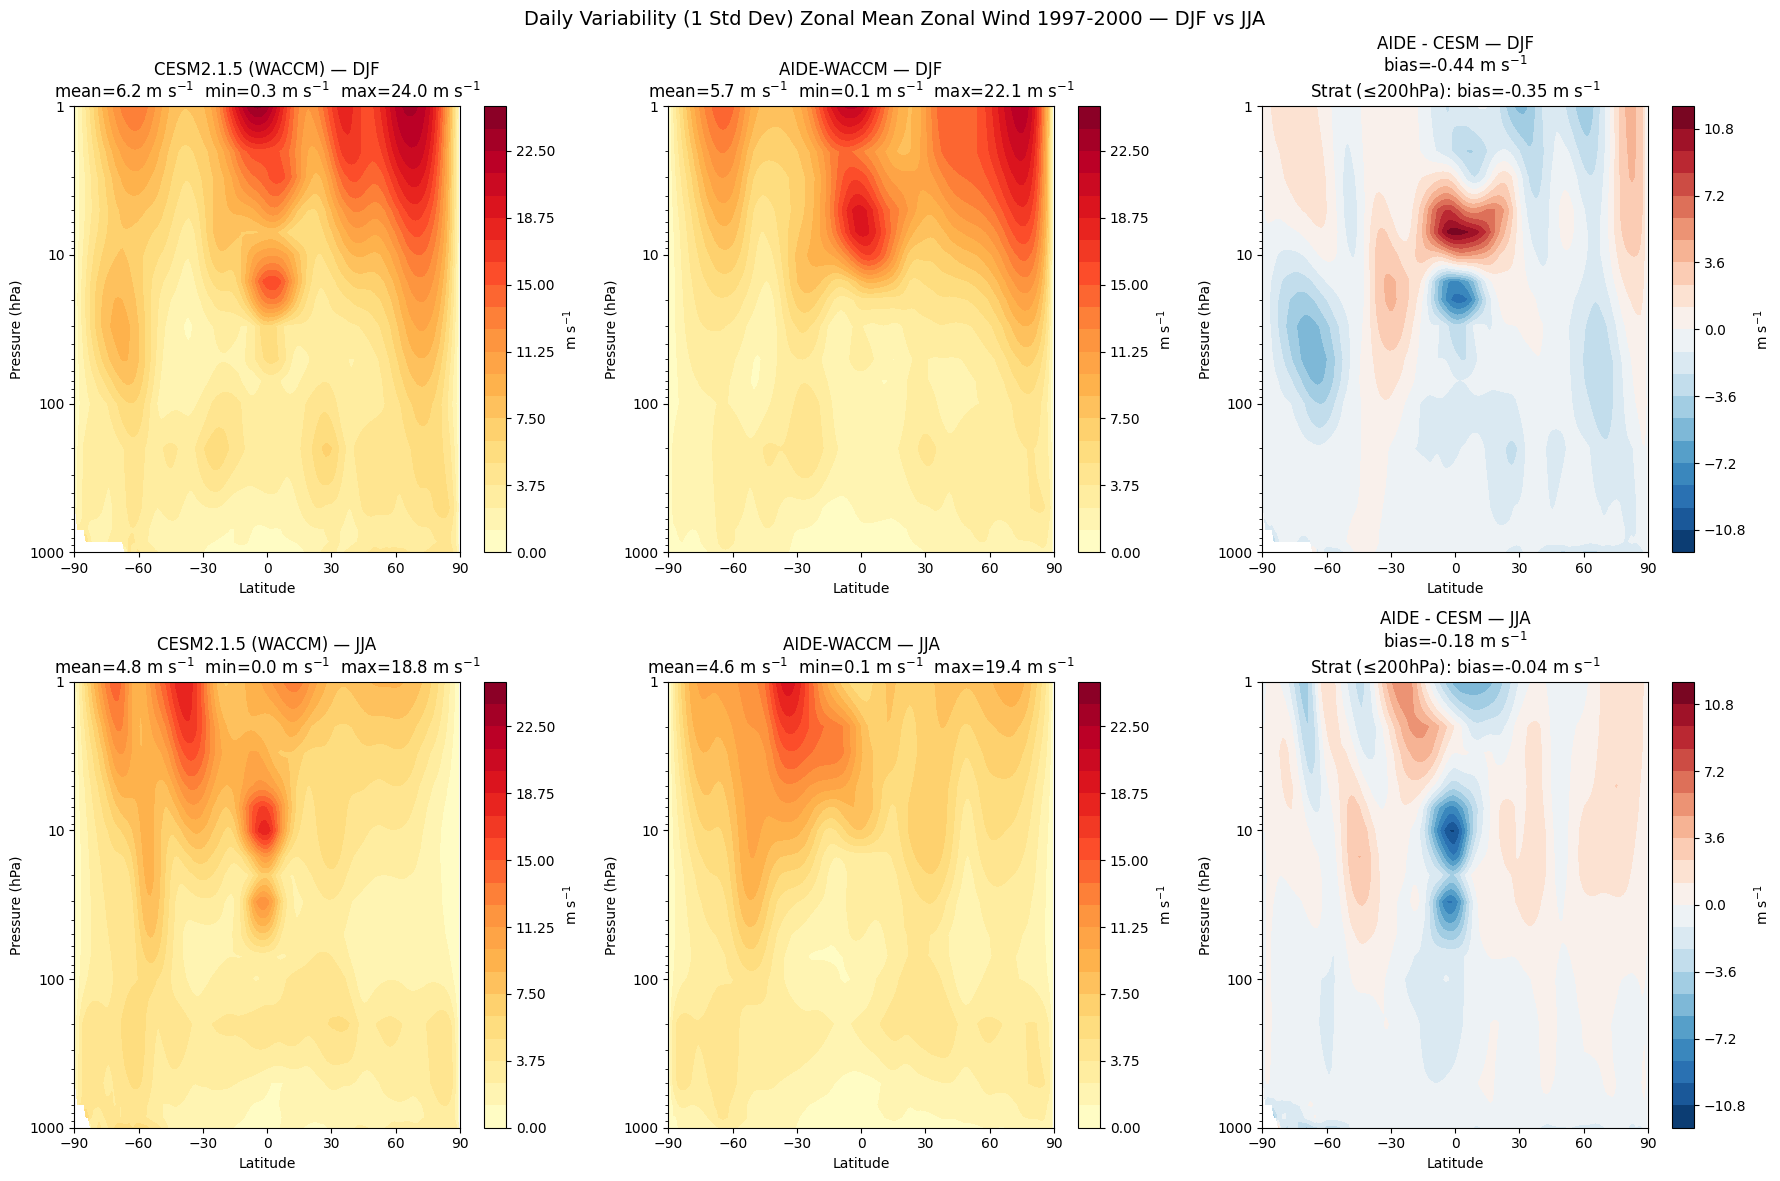

In [19]:
def compute_stats_U_std(aide, cesm):
    diff       = aide - cesm
    bias       = np.nanmean(diff)
    max_err    = np.nanmax(np.abs(diff))
    diff_strat = diff[strat_mask, :]
    bias_strat = np.nanmean(diff_strat)
    return diff, bias, max_err, bias_strat

def plot_row_U_std(axes, cesm, aide, season_label, levels, diff_levels):
    diff, bias, max_err, bias_strat = compute_stats_U_std(aide, cesm)

    cf1 = axes[0].contourf(lats, plevs, cesm, levels=levels, cmap='YlOrRd')
    axes[0].set_title(f'CESM2.1.5 (WACCM) — {season_label}\n'
                      f'mean={np.nanmean(cesm):.1f} m s$^{{-1}}$  '
                      f'min={np.nanmin(cesm):.1f} m s$^{{-1}}$  '
                      f'max={np.nanmax(cesm):.1f} m s$^{{-1}}$')

    cf2 = axes[1].contourf(lats, plevs, aide, levels=levels, cmap='YlOrRd')
    axes[1].set_title(f'AIDE-WACCM — {season_label}\n'
                      f'mean={np.nanmean(aide):.1f} m s$^{{-1}}$  '
                      f'min={np.nanmin(aide):.1f} m s$^{{-1}}$  '
                      f'max={np.nanmax(aide):.1f} m s$^{{-1}}$')

    cf3 = axes[2].contourf(lats, plevs, diff, levels=diff_levels, cmap='RdBu_r')
    axes[2].set_title(f'AIDE - CESM — {season_label}\n'
                      f'bias={bias:+.2f} m s$^{{-1}}$\n'
                      f'Strat (≤200hPa): bias={bias_strat:+.2f} m s$^{{-1}}$')

    for ax, cf, label in zip(axes, [cf1, cf2, cf3], ['m s$^{-1}$', 'm s$^{-1}$', 'm s$^{-1}$']):
        ax.set_yscale('log')
        ax.invert_yaxis()
        ax.set_ylabel('Pressure (hPa)')
        ax.set_xlabel('Latitude')
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        plt.colorbar(cf, ax=ax, label=label)

# ── figure ─────────────────────────────────────────────────────────────────
levels      = np.linspace(0, 25, 21)
diff_levels = np.linspace(-12, 12, 21)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_row_U_std(axes[0], U_DJF_std_cesm, U_DJF_std_aide, 'DJF', levels, diff_levels)
plot_row_U_std(axes[1], U_JJA_std_cesm, U_JJA_std_aide, 'JJA', levels, diff_levels)

plt.suptitle('Daily Variability (1 Std Dev) Zonal Mean Zonal Wind 1997-2000 — DJF vs JJA', fontsize=14)
plt.tight_layout()
plt.show()

## QBO and Polar Vortex Plots (Latitude Specific)

In [15]:
save_dir = "./1997_daily_means_aide/"

# Reload
U_zonal_array = np.load(f"{save_dir}/U_zonal_members_1997_2000.npy")
print(np.shape(U_zonal_array))

U_zonal_cesm = np.load('/home/ubuntu/noah/1997_2000_daily_means_cesm/U_zonal_cesm_1997_2000.npy')


lats = np.linspace(-89.5, 89.5, 180)
eq_idx = np.where((lats >= -5) & (lats <= 5))[0]
print(f"Equatorial indices: {eq_idx}, lats: {lats[eq_idx]}")
# AIDE
U_equator_array_members = []
for member in U_zonal_array:
    eq_arr = member[:, :, eq_idx].mean(axis=-1)  # average over 5°S-5°N
    U_equator_array_members.append(eq_arr)

U_equator_aide = np.nanmean(U_equator_array_members, axis=0)
print(f"AIDE shape: {U_equator_aide.shape}")

# CESM
U_equator_cesm = U_zonal_cesm[:, :, eq_idx].mean(axis=-1)  # average over 5°S-5°N
print(f"CESM shape: {U_equator_cesm.shape}")


(10, 1460, 17, 180)
Equatorial indices: [85 86 87 88 89 90 91 92 93 94], lats: [-4.5 -3.5 -2.5 -1.5 -0.5  0.5  1.5  2.5  3.5  4.5]
AIDE shape: (1460, 17)
CESM shape: (1460, 17)


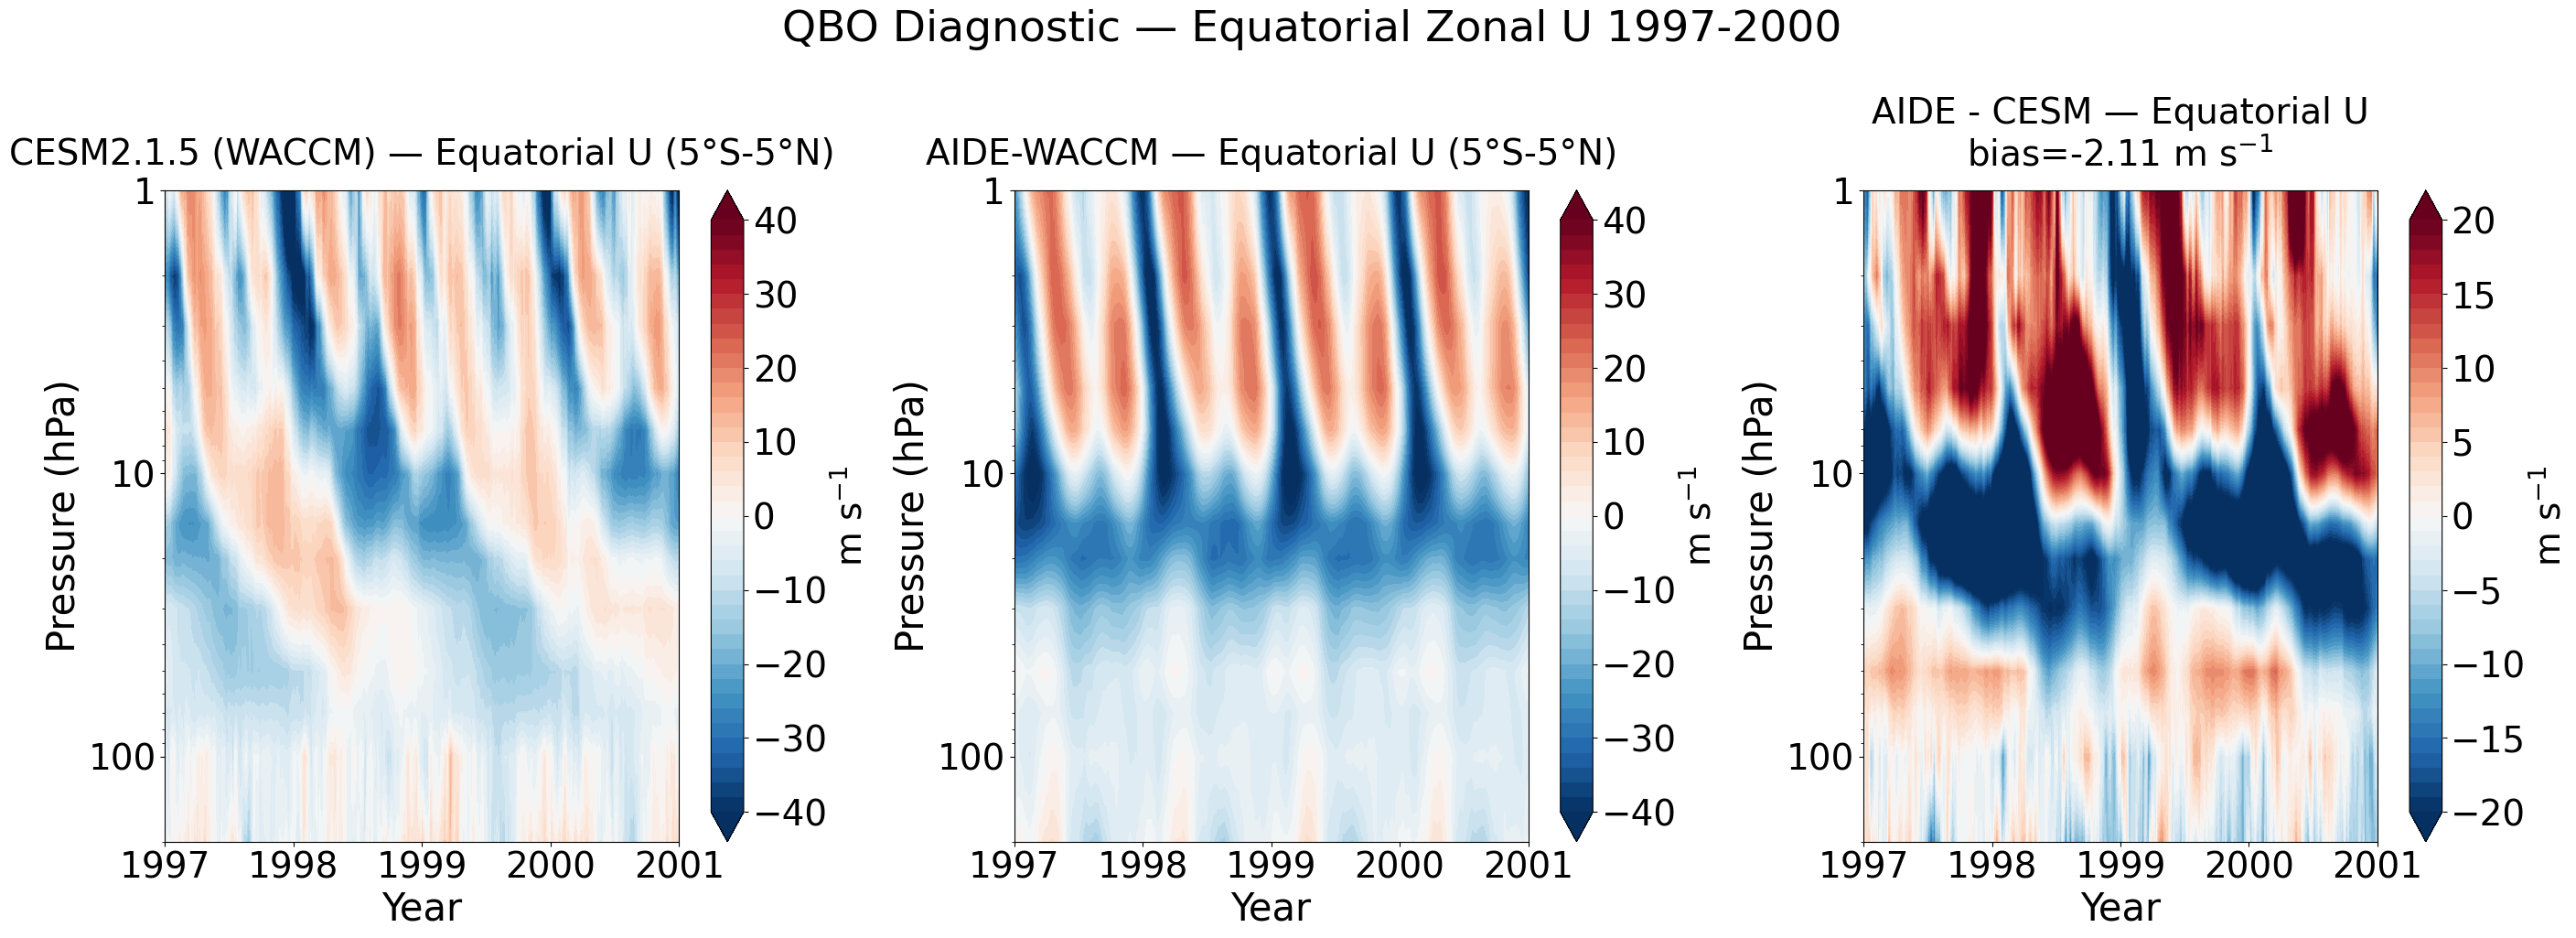

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import cftime
import datetime

start = cftime.DatetimeNoLeap(1997, 1, 1)
times = [start + datetime.timedelta(days=i) for i in range(1460)]
time_labels = [t.year + (t.dayofyr-1)/365 for t in times]

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])

# ── poster font sizes ───────────────────────────────────────────────────────
TITLE_FS    = 28
LABEL_FS    = 30
TICK_FS     = 28
CBAR_FS     = 28
SUPTITLE_FS = 34

levels      = np.linspace(-40, 40, 41)
diff_levels = np.linspace(-20, 20, 41)

diff_eq = U_equator_aide.T - U_equator_cesm.T

fig, axes = plt.subplots(1, 3, figsize=(28, 10))

# CESM
cf1 = axes[0].contourf(time_labels, plevs, U_equator_cesm.T, levels=levels, cmap='RdBu_r', extend='both')
axes[0].set_title('CESM2.1.5 (WACCM) — Equatorial U (5°S-5°N)', fontsize=TITLE_FS, pad=20)

# AIDE
cf2 = axes[1].contourf(time_labels, plevs, U_equator_aide.T, levels=levels, cmap='RdBu_r', extend='both')
axes[1].set_title('AIDE-WACCM — Equatorial U (5°S-5°N)', fontsize=TITLE_FS, pad=20)

# Difference
cf3 = axes[2].contourf(time_labels, plevs, diff_eq, levels=diff_levels, cmap='RdBu_r', extend='both')
axes[2].set_title(f'AIDE - CESM — Equatorial U\nbias={np.nanmean(diff_eq):+.2f} m s$^{{-1}}$',
                  fontsize=TITLE_FS, pad=20)

for ax, cf in zip(axes, [cf1, cf2, cf3]):
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)', fontsize=LABEL_FS)
    ax.set_xlabel('Year', fontsize=LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim([200, 1])
    ax.set_xticks([1997, 1998, 1999, 2000, 2001])
    ax.set_xticklabels(['1997', '1998', '1999', '2000', '2001'])
    cbar = plt.colorbar(cf, ax=ax, label='m s$^{-1}$')
    cbar.set_label('m s$^{-1}$', fontsize=CBAR_FS)
    cbar.ax.tick_params(labelsize=TICK_FS)

plt.suptitle('QBO Diagnostic — Equatorial Zonal U 1997-2000', fontsize=SUPTITLE_FS, y=1.02)
plt.tight_layout()
#plt.savefig('./presentation_figs/qbo_diagnostic_poster.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# 60°N polar vortex (NH, DJF)
nh_idx = np.where((lats >= 55) & (lats <= 65))[0]
print(f"NH indices: {nh_idx}, lats: {lats[nh_idx]}")

# 60°S polar vortex (SH, JJA)
sh_idx = np.where((lats >= -65) & (lats <= -55))[0]
print(f"SH indices: {sh_idx}, lats: {lats[sh_idx]}")

# AIDE
U_60N_array_members = []
U_60S_array_members = []
for member in U_zonal_array:
    U_60N_array_members.append(member[:, :, nh_idx].mean(axis=-1))
    U_60S_array_members.append(member[:, :, sh_idx].mean(axis=-1))

U_60N_aide = np.nanmean(U_60N_array_members, axis=0)  # (1460, 17)
U_60S_aide = np.nanmean(U_60S_array_members, axis=0)  # (1460, 17)

# CESM
U_60N_cesm = U_zonal_cesm[:, :, nh_idx].mean(axis=-1)  # (1460, 17)
U_60S_cesm = U_zonal_cesm[:, :, sh_idx].mean(axis=-1)  # (1460, 17)

print(f"AIDE 60N shape: {U_60N_aide.shape}, 60S shape: {U_60S_aide.shape}")
print(f"CESM 60N shape: {U_60N_cesm.shape}, 60S shape: {U_60S_cesm.shape}")

NH indices: [145 146 147 148 149 150 151 152 153 154], lats: [55.5 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5]
SH indices: [25 26 27 28 29 30 31 32 33 34], lats: [-64.5 -63.5 -62.5 -61.5 -60.5 -59.5 -58.5 -57.5 -56.5 -55.5]
AIDE 60N shape: (1460, 17), 60S shape: (1460, 17)
CESM 60N shape: (1460, 17), 60S shape: (1460, 17)


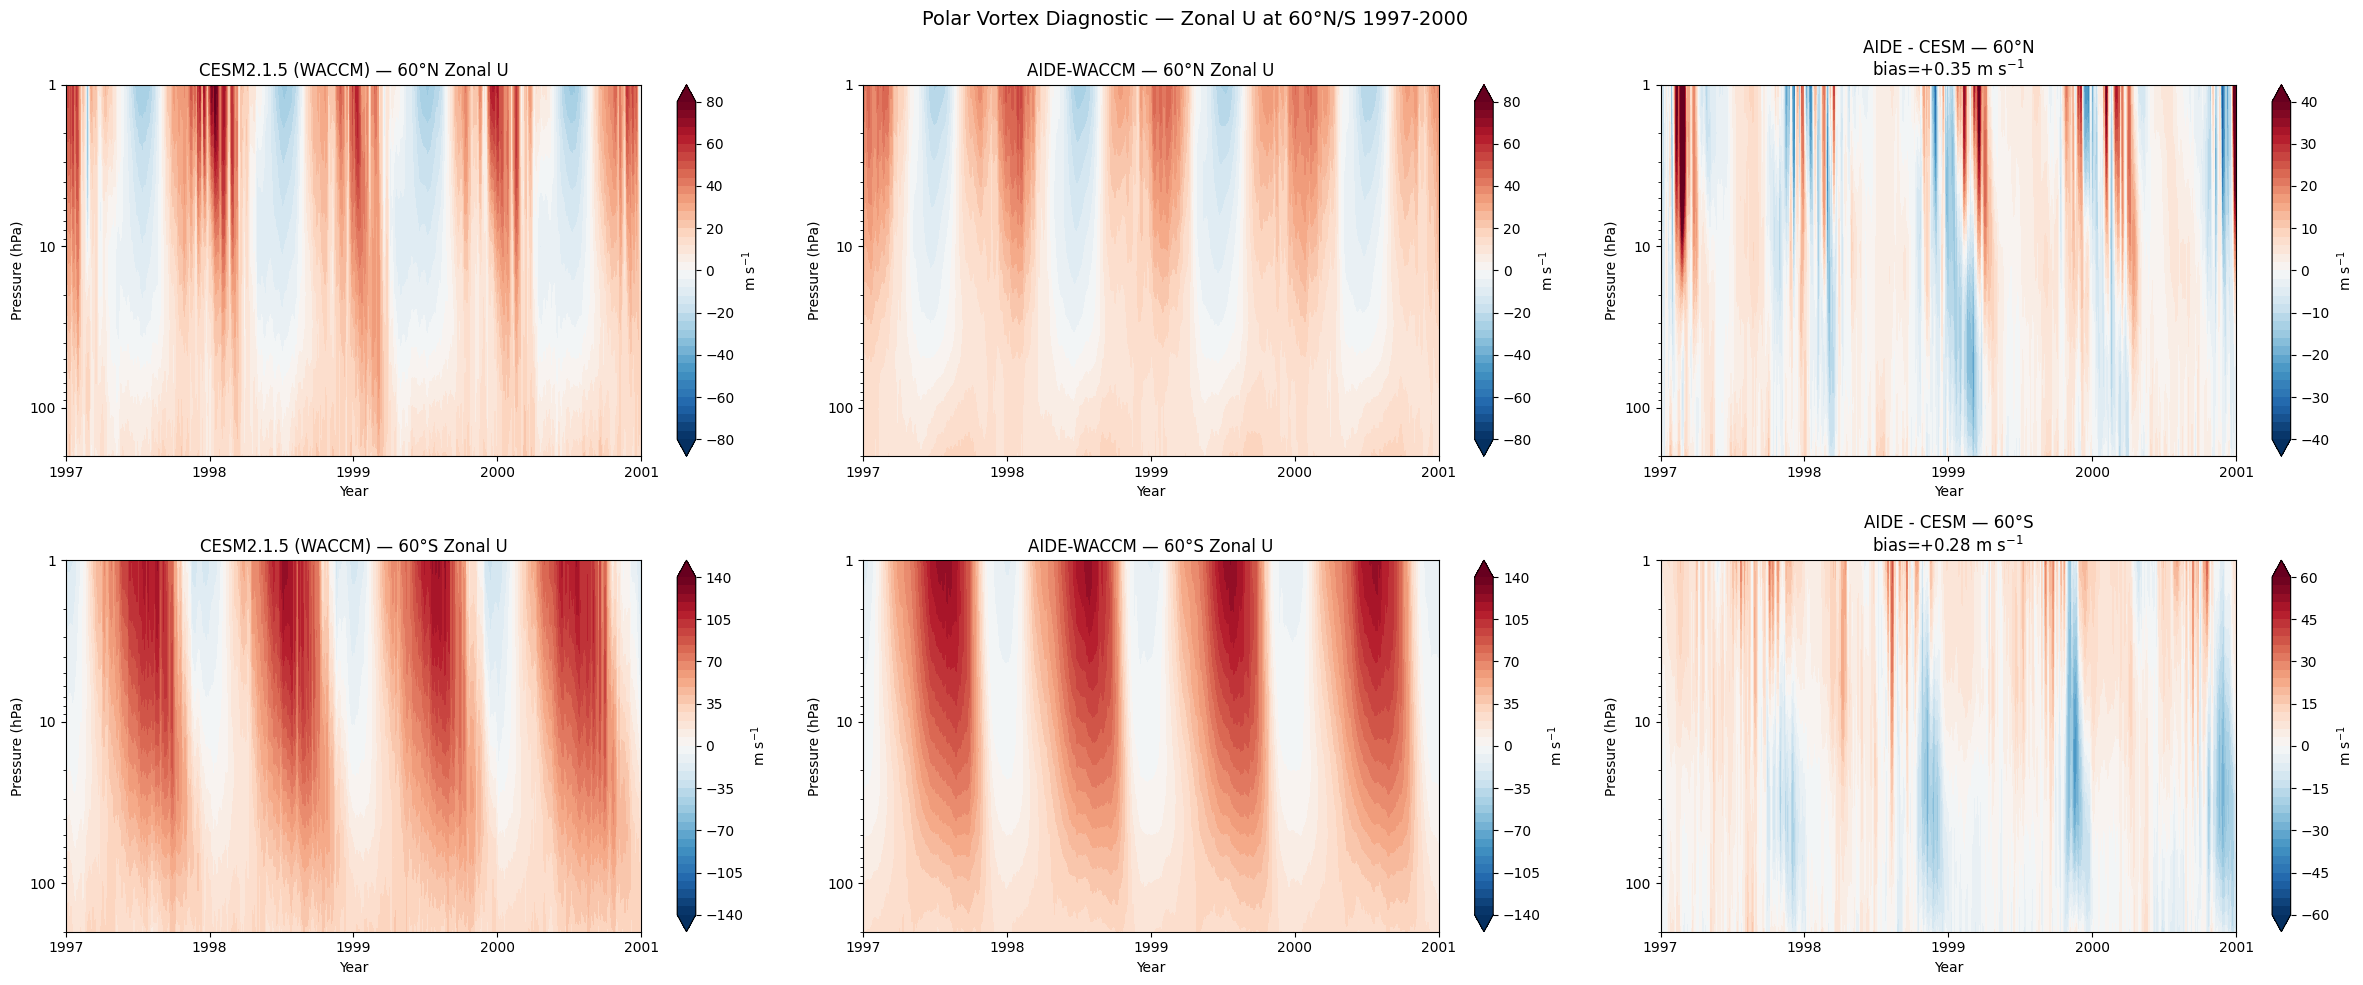

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plevs = np.array([1,2,3,5,7,10,15,20,30,50,70,100,200,500,700,850,1000])
start = cftime.DatetimeNoLeap(1997, 1, 1)
times = [start + datetime.timedelta(days=i) for i in range(1460)]
time_labels = [t.year + (t.dayofyr-1)/365 for t in times]

levels_NH     = np.linspace(-80, 80, 41)
levels_SH     = np.linspace(-140, 140, 41)
diff_levels_NH = np.linspace(-40, 40, 41)
diff_levels_SH = np.linspace(-60, 60, 41)

fig, axes = plt.subplots(2, 3, figsize=(24, 10))

# Row 0: 60°N
cf00 = axes[0, 0].contourf(time_labels, plevs, U_60N_cesm.T, levels=levels_NH, cmap='RdBu_r', extend='both')
axes[0, 0].set_title('CESM2.1.5 (WACCM) — 60°N Zonal U')

cf01 = axes[0, 1].contourf(time_labels, plevs, U_60N_aide.T, levels=levels_NH, cmap='RdBu_r', extend='both')
axes[0, 1].set_title('AIDE-WACCM — 60°N Zonal U')

diff_NH = U_60N_aide.T - U_60N_cesm.T
cf02 = axes[0, 2].contourf(time_labels, plevs, diff_NH, levels=diff_levels_NH, cmap='RdBu_r', extend='both')
axes[0, 2].set_title(f'AIDE - CESM — 60°N\nbias={np.nanmean(diff_NH):+.2f} m s$^{{-1}}$')

# Row 1: 60°S
cf10 = axes[1, 0].contourf(time_labels, plevs, U_60S_cesm.T, levels=levels_SH, cmap='RdBu_r', extend='both')
axes[1, 0].set_title('CESM2.1.5 (WACCM) — 60°S Zonal U')

cf11 = axes[1, 1].contourf(time_labels, plevs, U_60S_aide.T, levels=levels_SH, cmap='RdBu_r', extend='both')
axes[1, 1].set_title('AIDE-WACCM — 60°S Zonal U')

diff_SH = U_60S_aide.T - U_60S_cesm.T
cf12 = axes[1, 2].contourf(time_labels, plevs, diff_SH, levels=diff_levels_SH, cmap='RdBu_r', extend='both')
axes[1, 2].set_title(f'AIDE - CESM — 60°S\nbias={np.nanmean(diff_SH):+.2f} m s$^{{-1}}$')

for ax in axes.flat:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim([200, 1])
    ax.set_xticks([1997, 1998, 1999, 2000, 2001])
    ax.set_xticklabels(['1997', '1998', '1999', '2000', '2001'])

plt.colorbar(cf00, ax=axes[0, 0], label='m s$^{-1}$')
plt.colorbar(cf01, ax=axes[0, 1], label='m s$^{-1}$')
plt.colorbar(cf02, ax=axes[0, 2], label='m s$^{-1}$')
plt.colorbar(cf10, ax=axes[1, 0], label='m s$^{-1}$')
plt.colorbar(cf11, ax=axes[1, 1], label='m s$^{-1}$')
plt.colorbar(cf12, ax=axes[1, 2], label='m s$^{-1}$')

plt.suptitle('Polar Vortex Diagnostic — Zonal U at 60°N/S 1997-2000', fontsize=14)
plt.tight_layout()
plt.show()

## Conservation of Energy/Moisture

In [8]:
diag = pd.read_csv(
    "/data/paradis_logs/lightning_logs/cesm_run_2/forecasts/"
    "longrange_v2_dec1995_ensemble/1995_12_01_5y1m/online_diagnostics.csv"
)
print(diag.head())
print(diag.columns.tolist())

   step                           time    wall_s         M_dry         Mv  \
0    -1  1995-12-01T00:00:00.000000000  0.000000  10123.953975  24.721505   
1     0  1995-12-01T06:00:00.000000000  0.737869  10120.048328  26.390492   
2     1  1995-12-01T12:00:00.000000000  1.346292  10122.473168  25.153279   
3     2  1995-12-01T18:00:00.000000000  1.982477  10123.928967  24.350525   
4     3  1995-12-02T00:00:00.000000000  2.711456  10125.542073  24.062516   

              E  gamma_M_dry  gamma_Mv   gamma_E       T_min       T_max  \
0  3.373821e+09     1.000000  1.000000  1.000000  189.404297  305.089844   
1  3.376838e+09     0.999614  1.067512  1.000894  189.291382  313.298950   
2  3.374136e+09     0.999854  1.017466  1.000094  189.978806  312.209473   
3  3.372111e+09     0.999998  0.984994  0.999493  190.734726  305.516205   
4  3.371154e+09     1.000157  0.973343  0.999210  190.517792  304.762054   

      q_min     q_max        PS_min         PS_max  neg_dp_frac  
0  0.000001  0

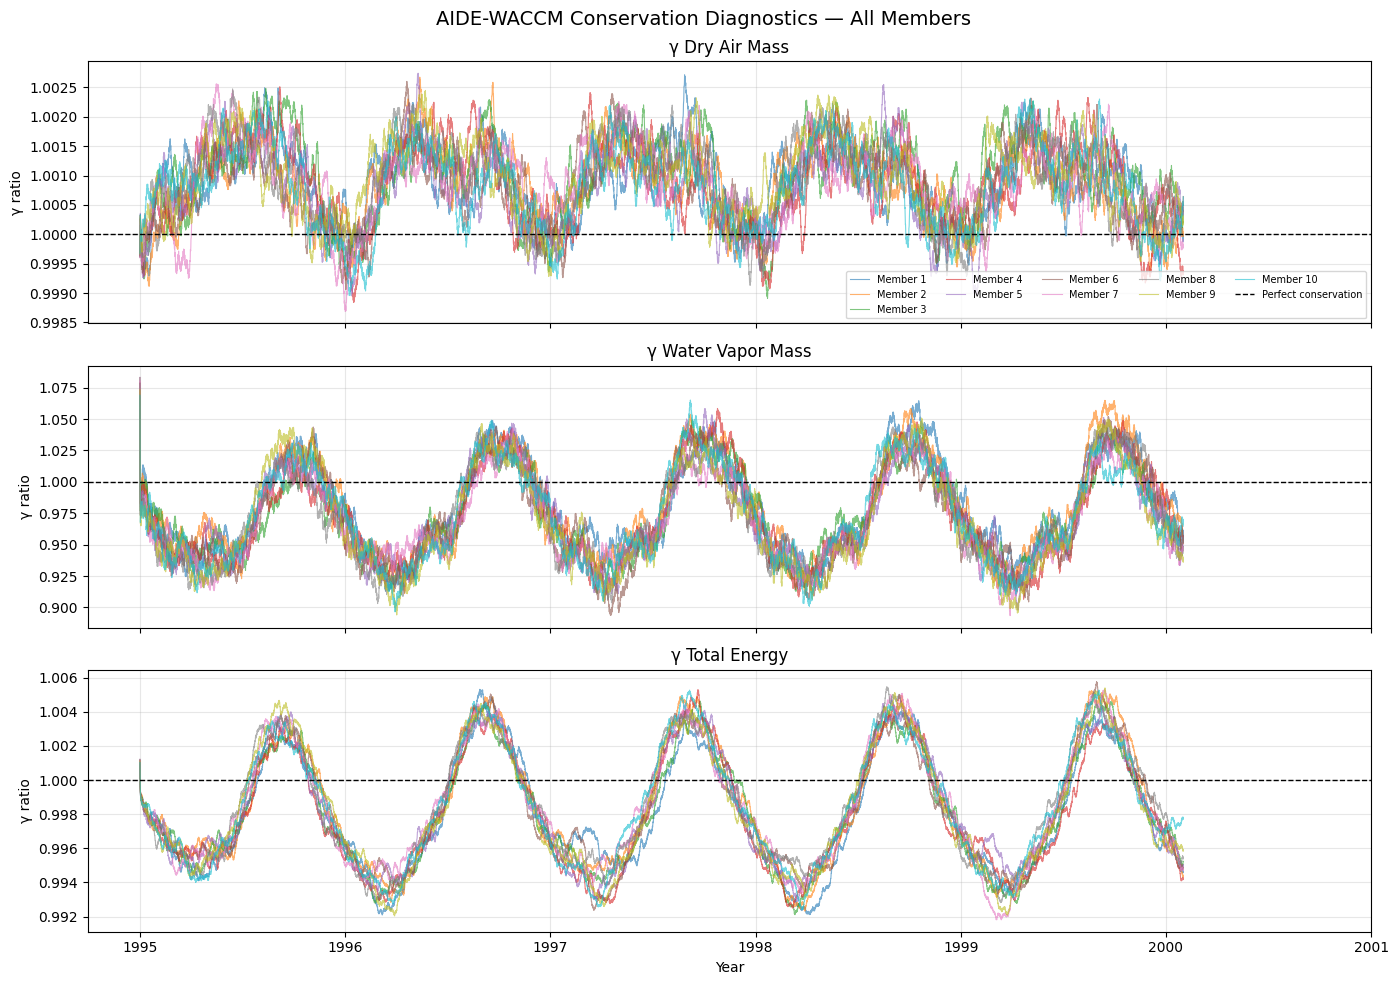

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

diag_paths = sorted(glob.glob(
    "/data/paradis_logs/lightning_logs/cesm_run_2/forecasts/"
    "longrange_v2_dec1995_ensemble/1995_12_*_5y1m/online_diagnostics.csv"
))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for mi, path in enumerate(diag_paths):
    diag = pd.read_csv(path)
    # Skip step=-1 (initial condition)
    diag = diag[diag['step'] >= 0]
    # Convert step to years
    time_years = 1995 + (diag['step'] * 6) / (365 * 24)
    
    axes[0].plot(time_years, diag['gamma_M_dry'], alpha=0.6, linewidth=0.8, label=f'Member {mi+1}')
    axes[1].plot(time_years, diag['gamma_Mv'],    alpha=0.6, linewidth=0.8)
    axes[2].plot(time_years, diag['gamma_E'],     alpha=0.6, linewidth=0.8)

for ax, title in zip(axes, ['γ Dry Air Mass', 'γ Water Vapor Mass', 'γ Total Energy']):
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, label='Perfect conservation')
    ax.set_ylabel('γ ratio')
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7, ncol=5)
axes[2].set_xlabel('Year')
axes[2].set_xticks([1995,1996, 1997, 1998, 1999, 2000, 2001])

plt.suptitle('AIDE-WACCM Conservation Diagnostics — All Members', fontsize=14)
plt.tight_layout()
plt.show()

## CLaMS (tracer work)

In [11]:
import netCDF4 as nc

clams = nc.Dataset('/data/CLaMS/CLaMS_v3/clams_reanalyses/clams_era5_zm_lat_press/clams_era5_zm_lat_press_2000.nc', mode='r')

print("Variables:", list(clams.variables.keys()))
print("Dimensions:", list(clams.dimensions.keys()))

for var in clams.variables.keys():
    v = clams.variables[var]
    print(f"  {var}: shape={v.shape}, units={getattr(v, 'units', 'N/A')}")

Variables: ['lat', 'press', 'month', 'GPH', 'TEMP', 'THETA', 'H2O_rea', 'U', 'V', 'THETA_DOT_TOT', 'TROP1_PRESS', 'TROP1_THETA', 'H2O', 'BA', 'CV', 'N2O', 'CH4', 'F11', 'F12', 'CO', 'CO2']
Dimensions: ['lat', 'press', 'month']
  lat: shape=(181,), units=deg N
  press: shape=(38,), units=hPa
  month: shape=(12,), units=month
  GPH: shape=(12, 38, 181), units=m**2/s**2
  TEMP: shape=(12, 38, 181), units=K
  THETA: shape=(12, 38, 181), units=K
  H2O_rea: shape=(12, 38, 181), units=m**3/m**3
  U: shape=(12, 38, 181), units=m/s
  V: shape=(12, 38, 181), units=m/s
  THETA_DOT_TOT: shape=(12, 38, 181), units=m**3/m**3
  TROP1_PRESS: shape=(12, 38, 181), units=m**3/m**3
  TROP1_THETA: shape=(12, 38, 181), units=m**3/m**3
  H2O: shape=(12, 38, 181), units=ppmv
  BA: shape=(12, 38, 181), units=yr
  CV: shape=(12, 38, 181), units=frac
  N2O: shape=(12, 38, 181), units=ppbv
  CH4: shape=(12, 38, 181), units=ppmv
  F11: shape=(12, 38, 181), units=pptv
  F12: shape=(12, 38, 181), units=pptv
  CO: sh

In [12]:
import netCDF4 as nc

# Check the main CLaMS transport file
f1 = nc.Dataset('/data/CLaMS/CLaMS_v3/ISSI_AoA/clams_tran_REN_HN2_era5_3d_24_1.5_19_19_lon_lat_theta.nc', mode='r')
print("=== clams_tran file ===")
print("Variables:", list(f1.variables.keys()))
print("Dimensions:", list(f1.dimensions.keys()))
for var in f1.variables.keys():
    v = f1.variables[var]
    print(f"  {var}: shape={v.shape}, units={getattr(v, 'units', 'N/A')}")

# Check the ERA5 file
f2 = nc.Dataset('/data/CLaMS/CLaMS_v3/ISSI_AoA/era5_19_19_lon_lat_theta.nc', mode='r')
print("\n=== era5 file ===")
print("Variables:", list(f2.variables.keys()))
for var in f2.variables.keys():
    v = f2.variables[var]
    print(f"  {var}: shape={v.shape}, units={getattr(v, 'units', 'N/A')}")

# Check the init file
f3 = nc.Dataset('/data/CLaMS/CLaMS_v3/ISSI_AoA/init_i3d_theta_19010112.nc', mode='r')
print("\n=== init file ===")
print("Variables:", list(f3.variables.keys()))
for var in f3.variables.keys():
    v = f3.variables[var]
    print(f"  {var}: shape={v.shape}, units={getattr(v, 'units', 'N/A')}")

=== clams_tran file ===
Variables: ['lat', 'lon', 'theta', 'month', 'BA', 'N2O']
Dimensions: ['lat', 'lon', 'theta', 'month']
  lat: shape=(231,), units=deg N
  lon: shape=(181,), units=deg E
  theta: shape=(31,), units=K
  month: shape=(12,), units=month
  BA: shape=(12, 31, 181, 231), units=yr
  N2O: shape=(12, 31, 181, 231), units=ppbv

=== era5 file ===
Variables: ['lat', 'lon', 'theta', 'month', 'TEMP', 'PRESS', 'THETA_DOT_TOT']
  lat: shape=(181,), units=deg N
  lon: shape=(360,), units=deg E
  theta: shape=(45,), units=K
  month: shape=(12,), units=month
  TEMP: shape=(12, 45, 360, 181), units=K
  PRESS: shape=(12, 45, 360, 181), units=hPa
  THETA_DOT_TOT: shape=(12, 45, 360, 181), units=m**3/m**3

=== init file ===
Variables: ['lat', 'lon', 'theta', 'BA', 'N2O', 'THETA', 'PRESS', 'TEMP', 'THETA_DOT_TOT']
  lat: shape=(181,), units=deg N
  lon: shape=(360,), units=deg E
  theta: shape=(31,), units=K
  BA: shape=(31, 181, 360), units=yr
  N2O: shape=(31, 181, 360), units=ppbv
  T

Pressure levels: [1.000000e+03 9.000000e+02 8.254040e+02 6.812920e+02 5.623410e+02
 4.641590e+02 3.831190e+02 3.162280e+02 2.610160e+02 2.154430e+02
 1.778280e+02 1.467800e+02 1.211530e+02 1.100000e+02 1.000000e+02
 9.000000e+01 8.254040e+01 7.500000e+01 6.812920e+01 6.000000e+01
 5.623410e+01 4.641590e+01 3.831190e+01 3.162280e+01 2.610160e+01
 2.154430e+01 1.467800e+01 1.000000e+01 6.812920e+00 4.641590e+00
 3.162280e+00 2.154430e+00 1.467800e+00 1.000000e+00 6.812921e-01
 4.641589e-01 2.154435e-01 1.000000e-01]
Lat range: -90.0 90.0
BA shape: (12, 38, 181)


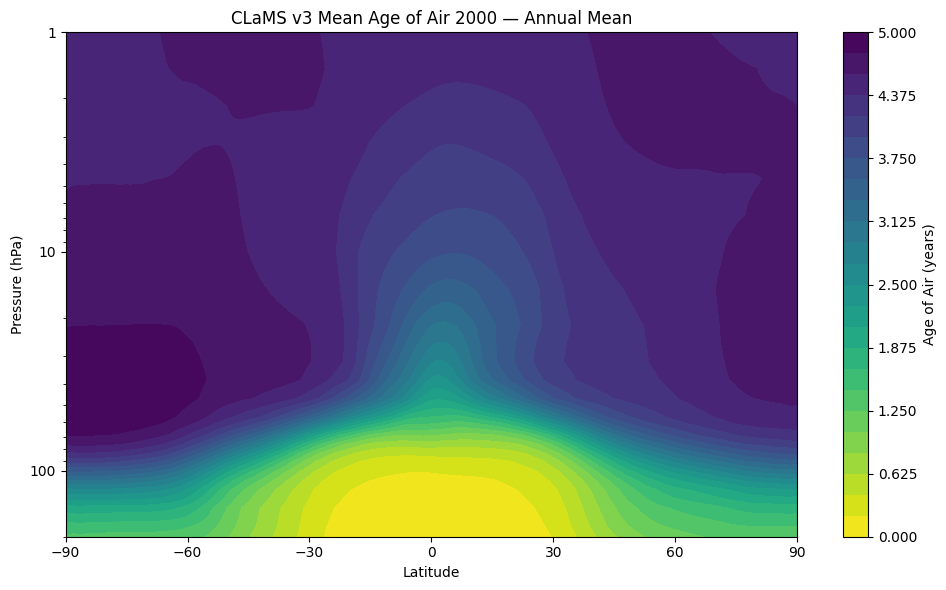

In [18]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load CLaMS 2000 (overlaps with your AIDE rollout end)
clams = nc.Dataset('/data/CLaMS/CLaMS_v3/clams_reanalyses/clams_era5_zm_lat_press/clams_era5_zm_lat_press_2000.nc', mode='r')

print("Pressure levels:", clams['press'][:])
print("Lat range:", clams['lat'][:].min(), clams['lat'][:].max())
print("BA shape:", clams['BA'].shape)  # (12, 38, 181)

# Annual mean age of air
BA_annual = np.nanmean(clams['BA'][:], axis=0)  # (38, 181) — mean over 12 months

lats_clams = clams['lat'][:]
press_clams = clams['press'][:]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
levels = np.linspace(0, 5, 25)  # age of air in years
cf = ax.contourf(lats_clams, press_clams, BA_annual, levels=levels, cmap='viridis_r')
ax.set_yscale('log')
ax.invert_yaxis()
ax.set_ylim([200, 1])  # focus on stratosphere
ax.set_ylabel('Pressure (hPa)')
ax.set_xlabel('Latitude')
ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.colorbar(cf, ax=ax, label='Age of Air (years)')
plt.title('CLaMS v3 Mean Age of Air 2000 — Annual Mean')
plt.tight_layout()
plt.show()

Loading v3: /home/ubuntu/noah/clams_v3/era5/clams_v3.1_era5_zm_lat_press_2004.nc
Loading v1 ERA5: /home/ubuntu/noah/clams_v1/era5/clams_v1.0_era5_zm_lat_press_2004.nc


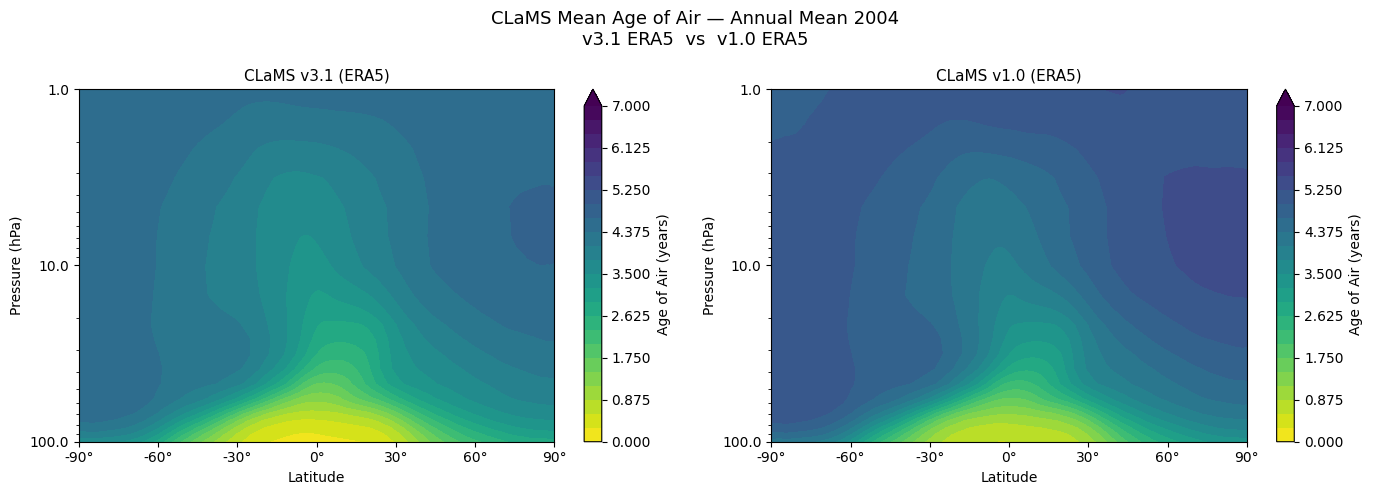

Loading v1 ERAin: /home/ubuntu/noah/clams_v1/erain/clams_v1.0_erain_zm_lat_press_2004.nc


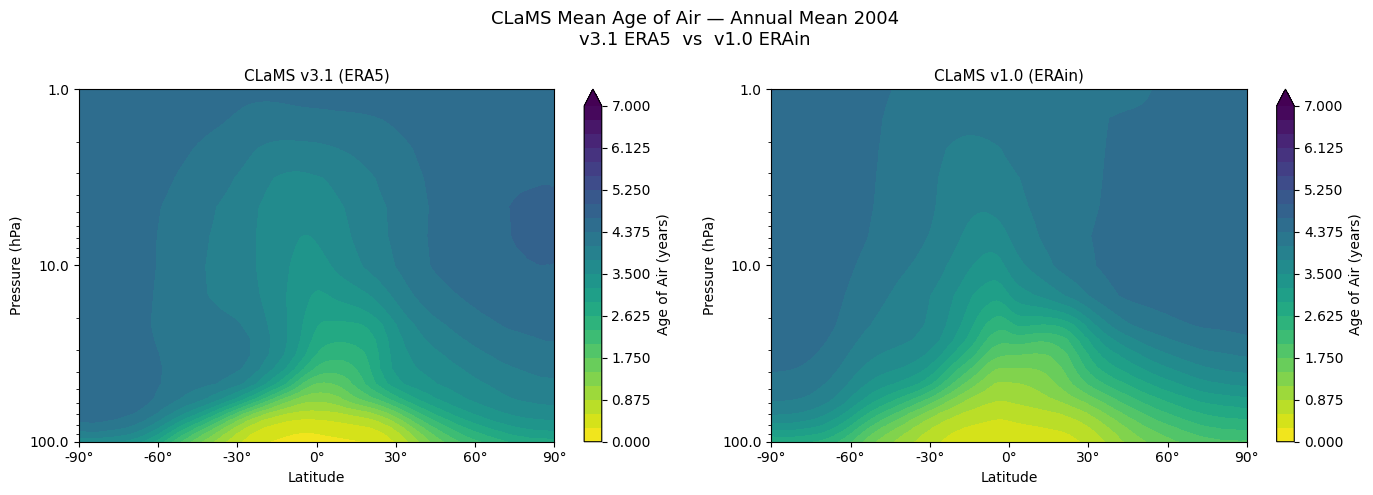

Loading v1 JRA-55: /home/ubuntu/noah/clams_v1/jra55/clams_v1.0_jra55_zm_lat_press_2004.nc


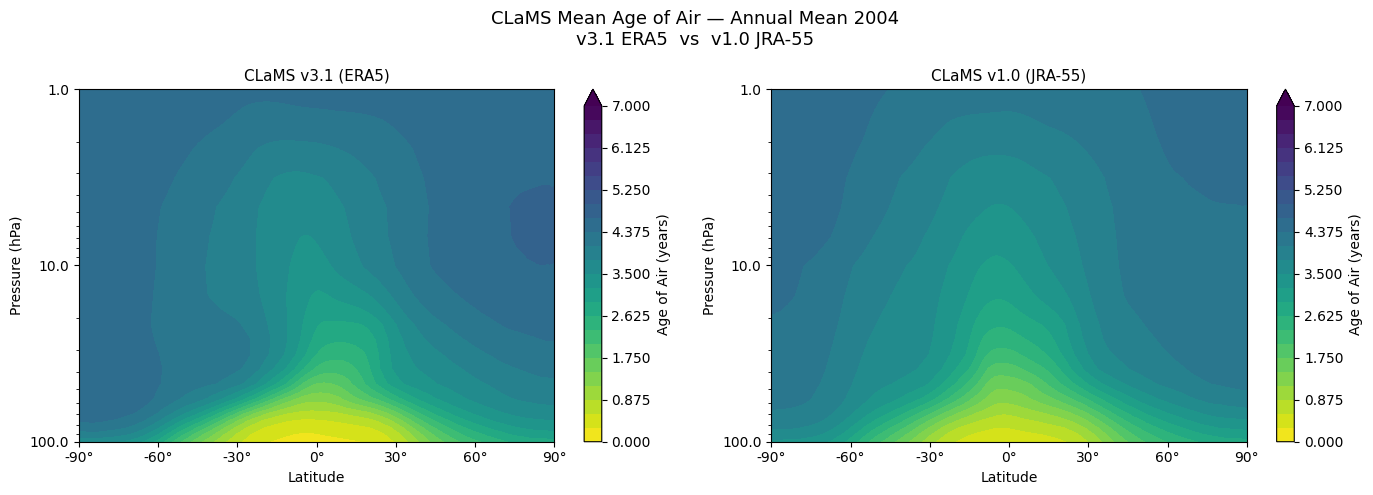

Loading v1 MERRA-2: /home/ubuntu/noah/clams_v1/merra2/clams_v1.0_merra2_zm_lat_press_2004.nc


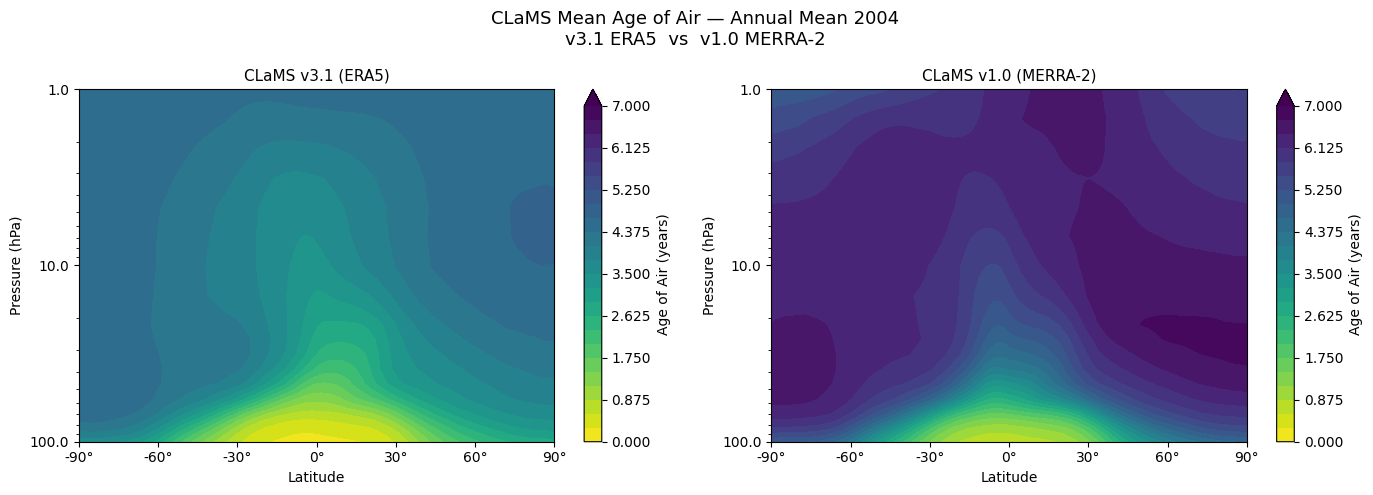

In [9]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── File paths ────────────────────────────────────────────────────────────────
V3_FILE = '/home/ubuntu/noah/clams_v3/era5/clams_v3.1_era5_zm_lat_press_2004.nc'

V1_FILES = {
    'ERA5':    '/home/ubuntu/noah/clams_v1/era5/clams_v1.0_era5_zm_lat_press_2004.nc',
    'ERAin':   '/home/ubuntu/noah/clams_v1/erain/clams_v1.0_erain_zm_lat_press_2004.nc',
    'JRA-55':  '/home/ubuntu/noah/clams_v1/jra55/clams_v1.0_jra55_zm_lat_press_2004.nc',
    'MERRA-2': '/home/ubuntu/noah/clams_v1/merra2/clams_v1.0_merra2_zm_lat_press_2004.nc',
}

MISSING_VAL = 1.0e-30
LEVELS      = np.linspace(0, 7, 25)
CMAP        = 'viridis_r'
YLIM        = (100, 1)


def load_annual_mean(filepath):
    ds  = nc.Dataset(filepath, mode='r')
    AGE = ds['AGE'][:].astype(float)
    AGE[AGE <= MISSING_VAL] = np.nan
    AGE_annual = np.nanmean(AGE, axis=0)   # (press, lat)
    lat = ds['lat'][:]
    prs = ds['press'][:]
    ds.close()
    return lat, prs, AGE_annual


def make_panel(ax, lats, press, AGE, title):
    cf = ax.contourf(lats, press, AGE, levels=LEVELS, cmap=CMAP, extend='max')
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylim(YLIM)
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d°'))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_title(title, fontsize=11)
    plt.colorbar(cf, ax=ax, label='Age of Air (years)')
    return cf


# ── Load v3 once ──────────────────────────────────────────────────────────────
print(f'Loading v3: {V3_FILE}')
lat_v3, prs_v3, AGE_v3 = load_annual_mean(V3_FILE)

# ── One figure per v1 reanalysis ──────────────────────────────────────────────
for label, v1_path in V1_FILES.items():
    if not Path(v1_path).exists():
        print(f'  !! File not found, skipping: {v1_path}')
        continue

    print(f'Loading v1 {label}: {v1_path}')
    lat_v1, prs_v1, AGE_v1 = load_annual_mean(v1_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'CLaMS Mean Age of Air — Annual Mean 2004\nv3.1 ERA5  vs  v1.0 {label}', fontsize=13)

    make_panel(axes[0], lat_v3, prs_v3, AGE_v3, 'CLaMS v3.1 (ERA5)')
    make_panel(axes[1], lat_v1, prs_v1, AGE_v1, f'CLaMS v1.0 ({label})')

    plt.tight_layout()
    plt.show()


Loading v3 ERA5 2004–2014...
Loading v1 ERA5 2004–2014...


/tmp/ipykernel_4175261/1102519775.py:46: RuntimeWarning: Mean of empty slice
  return lat, prs, np.nanmean(stacked, axis=0)   # (press, lat)


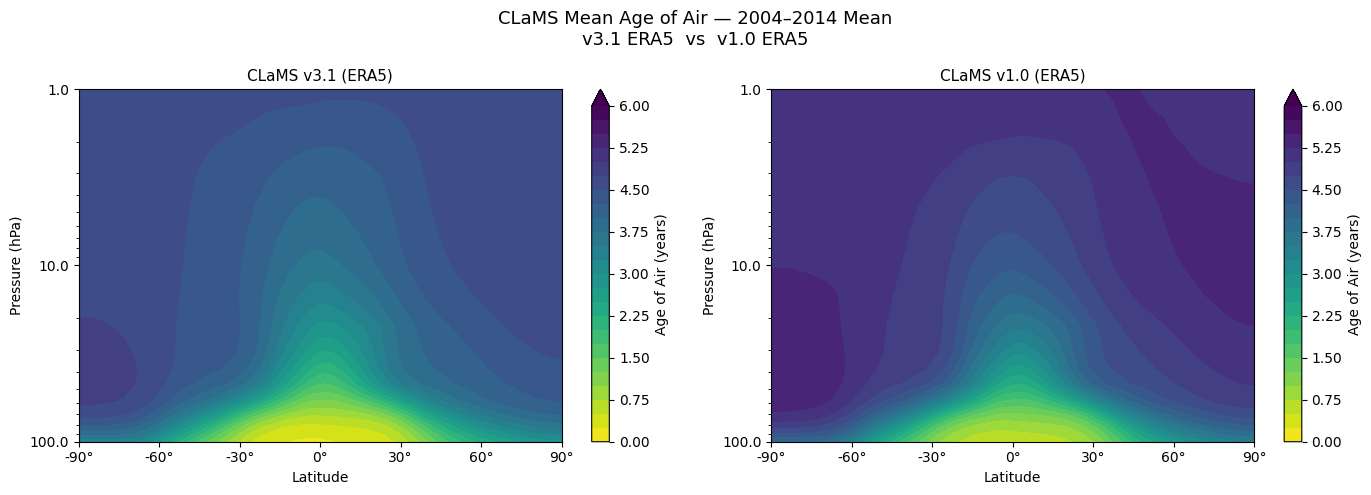

Loading v1 ERAin 2004–2014...


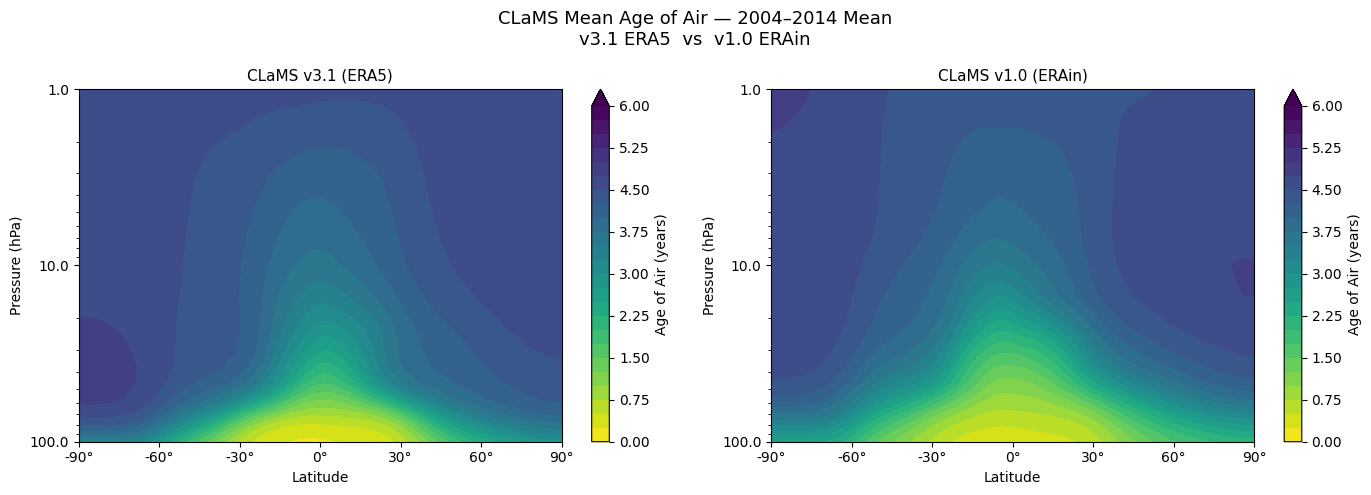

Loading v1 JRA-55 2004–2014...


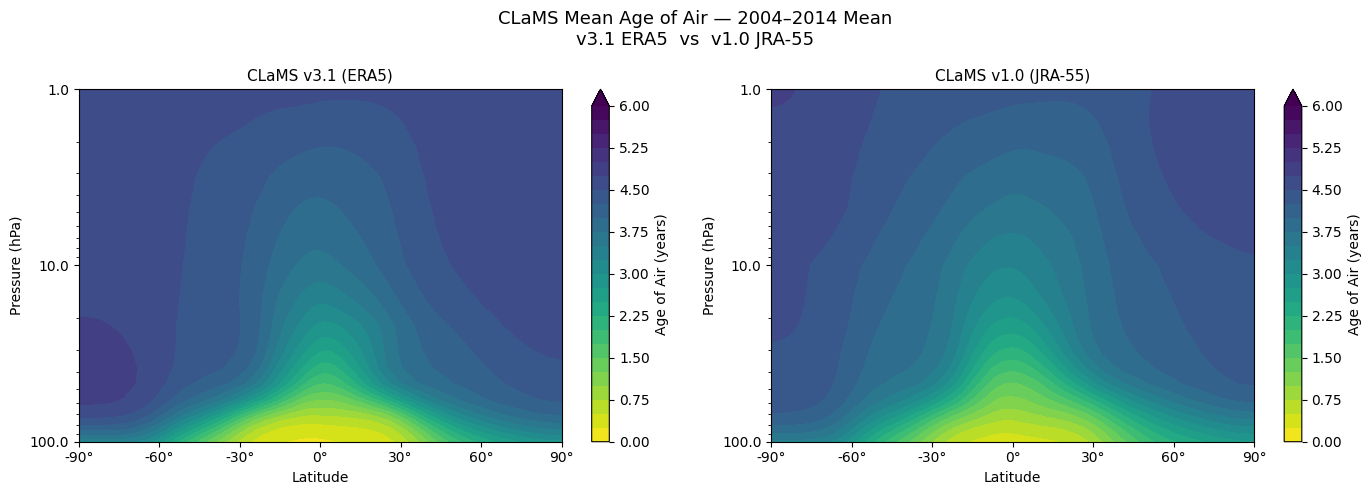

Loading v1 MERRA-2 2004–2014...


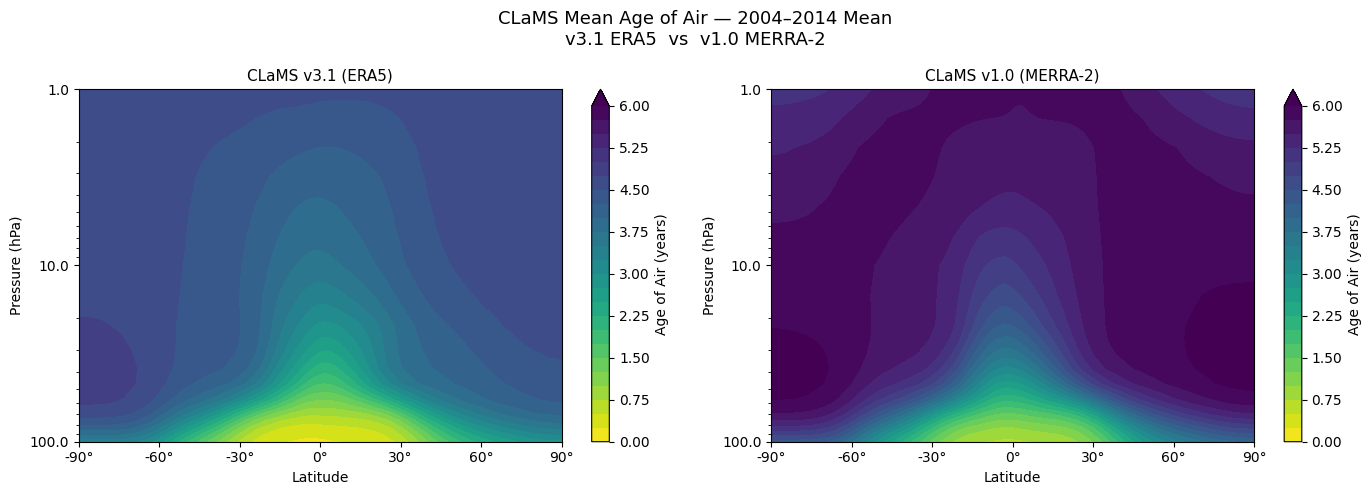

Done.


In [10]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
YEARS       = range(2004, 2015)   # 2004–2017 inclusive
MISSING_VAL = 1.0e-30
LEVELS      = np.linspace(0, 6, 25)
CMAP        = 'viridis_r'
YLIM        = (100, 1)

V3_BASE = '/home/ubuntu/noah/clams_v3/era5'
V3_PATTERN = 'clams_v3.1_era5_zm_lat_press_{year}.nc'

V1_BASE = '/home/ubuntu/noah/clams_v1'
V1_CONFIGS = {
    'ERA5':    ('era5',  'clams_v1.0_era5_zm_lat_press_{year}.nc'),
    'ERAin':   ('erain', 'clams_v1.0_erain_zm_lat_press_{year}.nc'),
    'JRA-55':  ('jra55', 'clams_v1.0_jra55_zm_lat_press_{year}.nc'),
    'MERRA-2': ('merra2','clams_v1.0_merra2_zm_lat_press_{year}.nc'),
}


def load_multiyear_mean(base, pattern, years):
    """Average AGE over all months across all available years in range."""
    all_months = []
    lat, prs = None, None
    for yr in years:
        fpath = Path(base) / pattern.format(year=yr)
        if not fpath.exists():
            print(f'    Missing: {fpath}, skipping year {yr}')
            continue
        ds  = nc.Dataset(fpath, mode='r')
        AGE = ds['AGE'][:].astype(float)   # (12, press, lat)
        AGE[AGE <= MISSING_VAL] = np.nan
        all_months.append(AGE)
        if lat is None:
            lat = ds['lat'][:]
            prs = ds['press'][:]
        ds.close()
    if not all_months:
        raise RuntimeError(f'No files found for pattern {pattern}')
    stacked = np.concatenate(all_months, axis=0)   # (n_months_total, press, lat)
    return lat, prs, np.nanmean(stacked, axis=0)   # (press, lat)


def make_panel(ax, lats, press, AGE, title):
    cf = ax.contourf(lats, press, AGE, levels=LEVELS, cmap=CMAP, extend='max')
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_ylim(YLIM)
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel('Latitude')
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d°'))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_title(title, fontsize=11)
    plt.colorbar(cf, ax=ax, label='Age of Air (years)')
    return cf


# ── Load v3 2004–2017 mean ────────────────────────────────────────────────────
print('Loading v3 ERA5 2004–2014...')
lat_v3, prs_v3, AGE_v3 = load_multiyear_mean(V3_BASE, V3_PATTERN, YEARS)

# ── One figure per v1 reanalysis ──────────────────────────────────────────────
for label, (subdir, pattern) in V1_CONFIGS.items():
    base = Path(V1_BASE) / subdir
    print(f'Loading v1 {label} 2004–2014...')
    lat_v1, prs_v1, AGE_v1 = load_multiyear_mean(base, pattern, YEARS)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'CLaMS Mean Age of Air — 2004–2014 Mean\nv3.1 ERA5  vs  v1.0 {label}',
        fontsize=13
    )

    make_panel(axes[0], lat_v3, prs_v3, AGE_v3, 'CLaMS v3.1 (ERA5)')
    make_panel(axes[1], lat_v1, prs_v1, AGE_v1, f'CLaMS v1.0 ({label})')

    plt.tight_layout()
    plt.show()

print('Done.')

## Testing

In [5]:
# ── setup ──────────────────────────────────────────────────────────────────
member_paths = sorted(glob.glob(
    "/data/paradis_logs/lightning_logs/cesm_run_2/forecasts/"
    "longrange_v2_dec1995_ensemble/1995_12_*_5y1m/state.zarr"
))
print(f"Found {len(member_paths)} members")

z0 = zarr.open_group(member_paths[0], mode='r')
feature_names   = z0['feature_names'][:]
feature_names

Found 10 members


array(['geopotential_h1', 'geopotential_h2', 'geopotential_h3',
       'geopotential_h5', 'geopotential_h7', 'geopotential_h10',
       'geopotential_h15', 'geopotential_h20', 'geopotential_h30',
       'geopotential_h50', 'geopotential_h70', 'geopotential_h100',
       'geopotential_h200', 'geopotential_h500', 'geopotential_h700',
       'geopotential_h850', 'geopotential_h1000', 'wind_x_h1',
       'wind_x_h2', 'wind_x_h3', 'wind_x_h5', 'wind_x_h7', 'wind_x_h10',
       'wind_x_h15', 'wind_x_h20', 'wind_x_h30', 'wind_x_h50',
       'wind_x_h70', 'wind_x_h100', 'wind_x_h200', 'wind_x_h500',
       'wind_x_h700', 'wind_x_h850', 'wind_x_h1000', 'wind_y_h1',
       'wind_y_h2', 'wind_y_h3', 'wind_y_h5', 'wind_y_h7', 'wind_y_h10',
       'wind_y_h15', 'wind_y_h20', 'wind_y_h30', 'wind_y_h50',
       'wind_y_h70', 'wind_y_h100', 'wind_y_h200', 'wind_y_h500',
       'wind_y_h700', 'wind_y_h850', 'wind_y_h1000', 'wind_z_h1',
       'wind_z_h2', 'wind_z_h3', 'wind_z_h5', 'wind_z_h7', 'wind_z_